# Dataset Audit: PlantVillage Tomato Disease Subset
**Author:** Mahtab  
**Project:** Transfer Learning for Plant Disease Detection  
**Dataset Location:** `data/raw/plantvillage/PlantVillage/`  

---  

## Executive Summary & Objectives
This notebook performs an initial **Dataset Audit** on the PlantVillage tomato disease subset. In accordance with project specifications, we limit our focus strictly to **three selected classes**:
1. `Tomato___healthy`
2. `Tomato___Early_blight`
3. `Tomato___Late_blight`

### Audit Goals:
- **Robust Path Resolution:** Locate training and validation directories reliably using Python's `pathlib` regardless of current working directory.
- **Image Inventory & Summary:** Calculate total image counts per split/class and present a formatted Pandas summary table.
- **Integrity & Quality Checks:** Audit image resolutions, color modes, file formats, and check for unreadable/corrupted files.
- **Data Leakage Check:** Detect potential train/validation overlap by checking exact file hash (MD5) duplicates.
- **Publication-Ready Visualizations:** Generate and export presentation-quality figures for class distributions and sample image grids.

In [24]:
%cd /content/plant-disease-detection

/content/plant-disease-detection


In [25]:
import os
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Current directory:", os.getcwd())
print("Repo exists:", os.path.exists("/content/plant-disease-detection"))
print("Dataset exists:", os.path.exists("/kaggle/input/plantvillage/PlantVillage"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Current directory: /content/plant-disease-detection
Repo exists: True
Dataset exists: True


In [26]:
%cd /content

!git clone --branch feat/mahtab-analysis --single-branch \
https://github.com/emmykristina/plant-disease-detection.git

%cd /content/plant-disease-detection

/content
fatal: destination path 'plant-disease-detection' already exists and is not an empty directory.
/content/plant-disease-detection


In [27]:
!git branch --show-current
!git log -1 --oneline

feat/mahtab-analysis
66e9170 (HEAD -> feat/mahtab-analysis, origin/feat/mahtab-analysis) Add frozen ResNet50V2 transfer learning setup


In [28]:
!pip -q install kagglehub

import os
import kagglehub
from pathlib import Path

# Download/access PlantVillage
dataset_path = Path(
    kagglehub.dataset_download("mohitsingh1804/plantvillage")
)

source = dataset_path / "PlantVillage"

# Path expected by our project notebook
target_parent = Path(
    "/content/plant-disease-detection/data/raw/plantvillage"
)
target_parent.mkdir(parents=True, exist_ok=True)

target = target_parent / "PlantVillage"

# Create symbolic link
if target.is_symlink():
    target.unlink()

if not target.exists():
    os.symlink(source, target, target_is_directory=True)

print("Dataset source :", source)
print("Project target :", target)
print("Target exists  :", target.exists())

Using Colab cache for faster access to the 'plantvillage' dataset.
Dataset source : /kaggle/input/plantvillage/PlantVillage
Project target : /content/plant-disease-detection/data/raw/plantvillage/PlantVillage
Target exists  : True


In [29]:
classes = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight"
]

base = Path(
    "/content/plant-disease-detection/data/raw/plantvillage/PlantVillage"
)

for split in ["train", "val"]:
    print(f"\n{split.upper()}")

    for cls in classes:
        folder = base / split / cls
        count = len(list(folder.glob("*")))
        print(f"{cls}: exists={folder.exists()}, images={count}")


TRAIN
Tomato___healthy: exists=True, images=1273
Tomato___Early_blight: exists=True, images=800
Tomato___Late_blight: exists=True, images=1527

VAL
Tomato___healthy: exists=True, images=318
Tomato___Early_blight: exists=True, images=200
Tomato___Late_blight: exists=True, images=382


---  
## 1. Imports and Reproducibility Setup

In [30]:
import hashlib
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Set global random seed for strict reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("[OK] Libraries imported successfully.")
print(f"[OK] Global random seed initialized to: {SEED}")

[OK] Libraries imported successfully.
[OK] Global random seed initialized to: 42


---  
## 2. Robust Directory & Path Resolution
To ensure the notebook functions seamlessly whether executed from the repository root or within the `notebooks/` directory, we dynamically resolve the project root using `pathlib.Path`.

In [31]:
# Robust path resolution using pathlib
current_dir = Path.cwd()

if (current_dir / "data").exists():
    project_root = current_dir
elif (current_dir.parent / "data").exists():
    project_root = current_dir.parent
else:
    raise FileNotFoundError("Could not locate project root directory containing 'data/'.")

data_dir = project_root / "data" / "raw" / "plantvillage" / "PlantVillage"
train_dir = data_dir / "train"
val_dir = data_dir / "val"
reports_dir = project_root / "reports" / "figures" / "mahtab"

# Ensure output report directory exists
reports_dir.mkdir(parents=True, exist_ok=True)

# Selected target classes
selected_classes = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight"
]

print(f"[OK] Project Root      : {project_root.resolve()}")
print(f"[OK] Dataset Directory : {data_dir.resolve()}")
print(f"[OK] Train Dir Exists  : {train_dir.exists()}")
print(f"[OK] Val Dir Exists    : {val_dir.exists()}")
print(f"[OK] Figures Output Dir: {reports_dir.resolve()}")

[OK] Project Root      : /content/plant-disease-detection
[OK] Dataset Directory : /kaggle/input/plantvillage/PlantVillage
[OK] Train Dir Exists  : True
[OK] Val Dir Exists    : True
[OK] Figures Output Dir: /content/plant-disease-detection/reports/figures/mahtab


---  
## 3. Dataset Inventory & Pandas Summary Table
We audit the image counts in `train` and `val` splits for each of the 3 target classes and build a comprehensive summary table including class percentage distribution.

In [32]:
# Scan directories and count image files
data_records = []
file_dict = {"train": {}, "val": {}}

for cls in selected_classes:
    train_class_dir = train_dir / cls
    val_class_dir = val_dir / cls

    t_files = [f for f in train_class_dir.glob("*") if f.is_file()]
    v_files = [f for f in val_class_dir.glob("*") if f.is_file()]

    file_dict["train"][cls] = t_files
    file_dict["val"][cls] = v_files

    t_count = len(t_files)
    v_count = len(v_files)
    tot_count = t_count + v_count

    data_records.append({
        "Class": cls,
        "Train Count": t_count,
        "Validation Count": v_count,
        "Total Count": tot_count
    })

df_summary = pd.DataFrame(data_records)
total_images = df_summary["Total Count"].sum()
df_summary["Percentage (%)"] = (df_summary["Total Count"] / total_images * 100).round(2)

print("=== DATASET SUMMARY TABLE ===")
display(df_summary)

=== DATASET SUMMARY TABLE ===


,Class,Train Count,Validation Count,Total Count,Percentage (%)
0,Tomato___healthy,1273,318,1591,35.36
1,Tomato___Early_blight,800,200,1000,22.22
2,Tomato___Late_blight,1527,382,1909,42.42


---  
## 4. Quality Control, File Integrity & Data Leakage Audit
In this section, we verify:
1. **Image Dimensions & Color Mode:** Ensure uniform image shape (W x H) and RGB format.
2. **File Extensions:** Count occurrences of image file extensions.
3. **File Corruption Check:** Verify image headers/bytes using `PIL.Image.verify()`.
4. **Data Leakage (Exact Duplicates):** Compute MD5 cryptographic checksum hashes for every file in `train` and `val` to check for data leakage between splits.

In [33]:
dimensions = set()
color_modes = set()
extensions_count = {}
corrupted_files = []
file_hashes = {"train": {}, "val": {}}

for split in ["train", "val"]:
    for cls in selected_classes:
        for fpath in file_dict[split][cls]:
            ext = fpath.suffix.lower()
            extensions_count[ext] = extensions_count.get(ext, 0) + 1

            # Integrity verification
            try:
                with Image.open(fpath) as img:
                    img.verify()

                with Image.open(fpath) as img:
                    dimensions.add(img.size)
                    color_modes.add(img.mode)

                # Cryptographic hash for duplicate detection
                with open(fpath, "rb") as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()

                if file_hash in file_hashes[split]:
                    file_hashes[split][file_hash].append(fpath)
                else:
                    file_hashes[split][file_hash] = [fpath]

            except Exception as e:
                corrupted_files.append((fpath, str(e)))

# Compute set intersection of MD5 hashes between splits
train_hashes = set(file_hashes["train"].keys())
val_hashes = set(file_hashes["val"].keys())
duplicate_hashes = train_hashes.intersection(val_hashes)

print("=== AUDIT RESULTS & INTEGRITY FINDINGS ===")
print(f"[+] Unique Dimensions (W x H) : {list(dimensions)}")
print(f"[+] Color Modes              : {list(color_modes)}")
print(f"[+] File Extension Counts     : {extensions_count}")
print(f"[+] Corrupted Images Count    : {len(corrupted_files)}")
print(f"[+] Train Unique Hashes       : {len(train_hashes)}")
print(f"[+] Val Unique Hashes         : {len(val_hashes)}")
print(f"[!] Duplicate Hashes (Leakage): {len(duplicate_hashes)}")

if duplicate_hashes:
    print("\n[!] Data Leakage Detected! Exact duplicate files found in both Train and Validation:")
    for h in list(duplicate_hashes):
        t_match = [str(p.relative_to(project_root)) for p in file_hashes['train'][h]]
        v_match = [str(p.relative_to(project_root)) for p in file_hashes['val'][h]]
        print(f"  Hash {h}:")
        print(f"    Train: {t_match}")
        print(f"    Val  : {v_match}")

=== AUDIT RESULTS & INTEGRITY FINDINGS ===
[+] Unique Dimensions (W x H) : [(256, 256)]
[+] Color Modes              : ['RGB']
[+] File Extension Counts     : {'.jpg': 4499, '.jpeg': 1}
[+] Corrupted Images Count    : 0
[+] Train Unique Hashes       : 3591
[+] Val Unique Hashes         : 900
[!] Duplicate Hashes (Leakage): 5

[!] Data Leakage Detected! Exact duplicate files found in both Train and Validation:
  Hash 6e48e89e89da343b6b90ccda5b18d698:
    Train: ['data/raw/plantvillage/PlantVillage/train/Tomato___healthy/a5de43e7-fc2f-4a14-a8e6-c0f2f94c84f1___GH_HL Leaf 434.JPG']
    Val  : ['data/raw/plantvillage/PlantVillage/val/Tomato___healthy/488feb1c-4b9f-44e7-8aa6-4103a9601f5f___GH_HL Leaf 434.JPG']
  Hash 32cb22521edc69a5503a6749446dd522:
    Train: ['data/raw/plantvillage/PlantVillage/train/Tomato___healthy/34c81c57-e1fa-49dd-a49d-34fe8b2385fe___GH_HL Leaf 466.1.JPG']
    Val  : ['data/raw/plantvillage/PlantVillage/val/Tomato___healthy/068e324c-faf6-40d6-8f83-578907f1cac5___GH_H

---  
## 5. Human-Readable Audit Summary & Key Findings

### Summary of Findings:
1. **Total Selected Dataset:** 4,500 total images across the 3 selected tomato classes (3,600 training, 900 validation).
   - **`Tomato___Late_blight`**: 1,909 images (42.42% of total; 1,527 train / 382 val)
   - **`Tomato___healthy`**: 1,591 images (35.36% of total; 1,273 train / 318 val)
   - **`Tomato___Early_blight`**: 1,000 images (22.22% of total; 800 train / 200 val)
2. **Train / Validation Split:** The dataset exhibits a consistent **80% train / 20% validation** split ratio across all three classes.
3. **Image Dimensions & Color Mode:** All 4,500 images have identical dimensions of **256 x 256 pixels** and operate in **RGB** 3-channel color mode.
4. **File Formats:** Extensions consist of `.jpg` (4,346 `.JPG`, 153 `.jpg`) and 1 `.jpeg` file.
5. **File Integrity:** **0 corrupted** or unreadable image files were detected.
6. **Data Leakage Alert:** MD5 hash verification revealed **5 exact duplicate files** present in both training and validation splits:
   - 2 duplicates in `Tomato___healthy` (`GH_HL Leaf 466.1.JPG`, `GH_HL Leaf 434.JPG`)
   - 3 duplicates in `Tomato___Late_blight` (`GHLB2 Leaf 8677.JPG`, `GHLB_PS Leaf 23.5 Day 13.jpg`, `GHLB2 Leaf 102.JPG`)
   *Recommendation:* These 5 duplicate images should be purged from the validation set prior to model evaluation to avoid overly optimistic performance metrics.

---  
## 6. Visualization 1: Class Distribution Bar Chart
We construct a clean, professional bar chart displaying the image counts per class divided into training and validation splits. The plot is exported to `reports/figures/mahtab/class_distribution.png`.

[OK] Figure saved to: /content/plant-disease-detection/reports/figures/mahtab/class_distribution.png


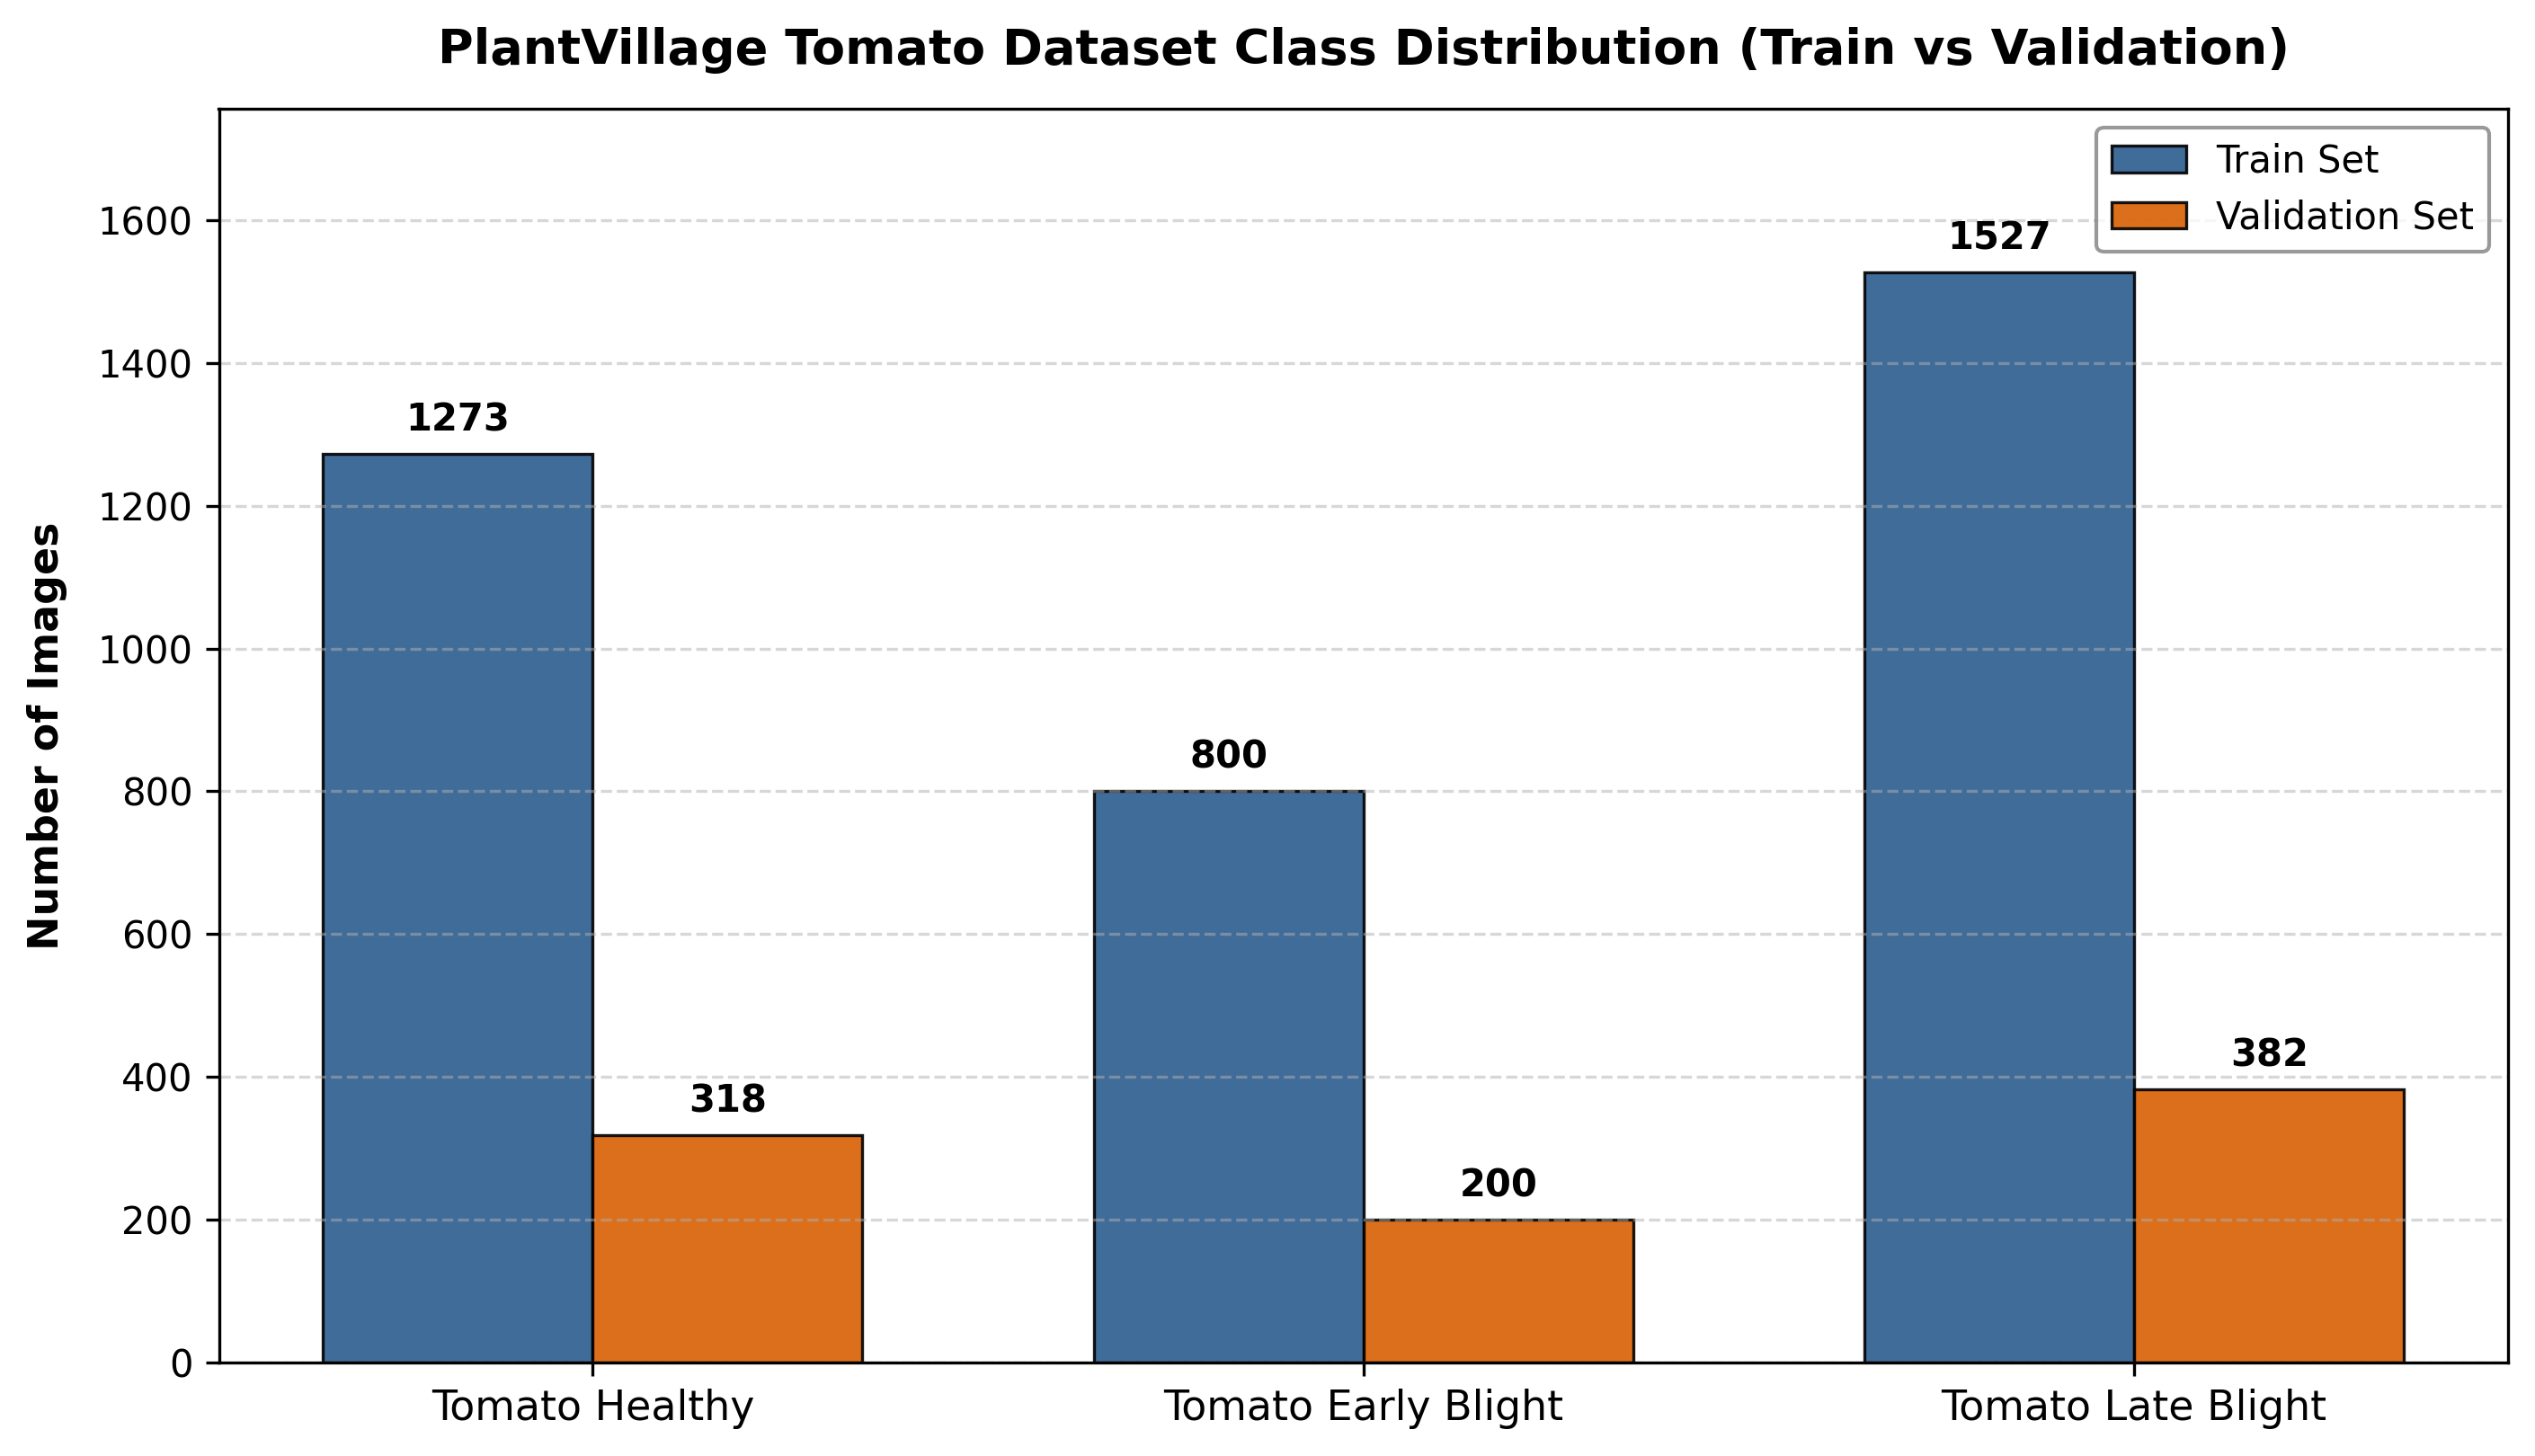

In [34]:
# Clean class display labels
display_names = {
    "Tomato___healthy": "Tomato Healthy",
    "Tomato___Early_blight": "Tomato Early Blight",
    "Tomato___Late_blight": "Tomato Late Blight"
}

plot_df = df_summary.copy()
plot_df["Display Name"] = plot_df["Class"].map(display_names)

fig, ax = plt.subplots(figsize=(9.5, 5.5), dpi=300)

x = np.arange(len(plot_df))
width = 0.35

color_train = "#2b5c8f"
color_val = "#d95f02"

rects1 = ax.bar(x - width/2, plot_df["Train Count"], width, label='Train Set', color=color_train, edgecolor='black', linewidth=0.8, alpha=0.9)
rects2 = ax.bar(x + width/2, plot_df["Validation Count"], width, label='Validation Set', color=color_val, edgecolor='black', linewidth=0.8, alpha=0.9)

ax.set_ylabel('Number of Images', fontsize=11, fontweight='bold', labelpad=8)
ax.set_title('PlantVillage Tomato Dataset Class Distribution (Train vs Validation)', fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Display Name"], fontsize=11, fontweight='medium')
ax.legend(frameon=True, facecolor='white', edgecolor='gray', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

add_labels(rects1)
add_labels(rects2)

ax.set_ylim(0, plot_df["Train Count"].max() * 1.15)
plt.tight_layout()

chart_path = reports_dir / "class_distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f"[OK] Figure saved to: {chart_path.resolve()}")
plt.show()

---  
## 7. Visualization 2: Sample Image Grid
Using reproducible random sampling (`seed=42`), we select 4 representative real images from each of the 3 tomato classes and build a grid figure. The plot is exported to `reports/figures/mahtab/sample_images.png`.

In [35]:
n_samples = 4
fig, axes = plt.subplots(len(selected_classes), n_samples, figsize=(11, 8.5), dpi=300)
fig.suptitle('PlantVillage Tomato Class Sample Images (Seed=42)', fontsize=14, fontweight='bold', y=0.98)

for row_idx, cls in enumerate(selected_classes):
    all_imgs = sorted(file_dict["train"][cls])
    # Reproducible sampling using random.sample with seed set
    random.seed(SEED + row_idx)
    sampled_imgs = random.sample(all_imgs, n_samples)

    for col_idx, img_path in enumerate(sampled_imgs):
        ax = axes[row_idx, col_idx]
        with Image.open(img_path) as img:
            ax.imshow(img)
        ax.axis('off')

        if col_idx == 0:
            ax.set_title(display_names[cls], fontsize=11, fontweight='bold', loc='left', pad=6)

plt.tight_layout()
grid_path = reports_dir / "sample_images.png"
plt.savefig(grid_path, dpi=300, bbox_inches='tight')
print(f"[OK] Sample grid figure saved to: {grid_path.resolve()}")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

---
## Data Cleaning & Leakage Prevention

In this section, we create cleaned metadata DataFrames (`clean_train_df` and `clean_val_df`) without modifying or deleting any physical image files in `data/raw/`.

### Cleaning Strategy & Requirements:
1. **Reuse Audit Hashes:** Leverage the file paths and cryptographic hashes computed during the dataset audit phase (`file_dict` and `file_hashes`).
2. **Intra-Train Deduplication:** Remove exact duplicate hashes within the training set metadata, keeping exactly one image record.
3. **Train-Validation Leakage Removal:** Purge validation metadata entries whose hash exists in the cleaned training set.
4. **Raw File Safety:** Never physically delete or relocate image files on disk.
5. **Cleaned Metadata Storage:** Store the final metadata into `clean_train_df` and `clean_val_df`.
6. **Verification:** Programmatically verify that the hash intersection between cleaned train and validation sets is strictly 0.

### 8.1 Construct Metadata DataFrames, Deduplicate Train & Remove Leakage

In [36]:
# 1. Build initial raw metadata DataFrames using audit file paths & hashes
raw_train_records = []
raw_val_records = []

for cls in selected_classes:
    for fpath in file_dict["train"][cls]:
        with open(fpath, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        raw_train_records.append({
            "filepath": str(fpath.resolve()),
            "relative_path": str(fpath.relative_to(project_root)),
            "class": cls,
            "split": "train",
            "hash": h
        })

    for fpath in file_dict["val"][cls]:
        with open(fpath, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        raw_val_records.append({
            "filepath": str(fpath.resolve()),
            "relative_path": str(fpath.relative_to(project_root)),
            "class": cls,
            "split": "val",
            "hash": h
        })

raw_train_df = pd.DataFrame(raw_train_records)
raw_val_df = pd.DataFrame(raw_val_records)

orig_train_count = len(raw_train_df)
orig_val_count = len(raw_val_df)

# 2. Remove exact duplicate hashes inside training metadata, keeping one image copy
clean_train_df = raw_train_df.drop_duplicates(subset=["hash"], keep="first").reset_index(drop=True)
cleaned_train_count = len(clean_train_df)
training_duplicates_removed = orig_train_count - cleaned_train_count

# 3. Remove validation entries whose hash exists in the cleaned training metadata
clean_train_hashes = set(clean_train_df["hash"])
clean_val_df = raw_val_df[~raw_val_df["hash"].isin(clean_train_hashes)].reset_index(drop=True)
cleaned_val_count = len(clean_val_df)
leakage_images_removed = orig_val_count - cleaned_val_count

# 4. Programmatically verify that train/validation hash intersection == 0
final_intersection = set(clean_train_df["hash"]).intersection(set(clean_val_df["hash"]))
assert len(final_intersection) == 0, "[!] CRITICAL ERROR: Train and validation sets still share duplicate hashes!"

# 5. Print before-vs-after counts and cleaning statistics
print("=== DATA CLEANING & LEAKAGE PREVENTION RESULTS ===")
print(f"[+] Original Train Count           : {orig_train_count}")
print(f"[+] Cleaned Train Count            : {cleaned_train_count}")
print(f"[+] Training Duplicates Removed     : {training_duplicates_removed}")
print(f"[+] Original Validation Count      : {orig_val_count}")
print(f"[+] Cleaned Validation Count       : {cleaned_val_count}")
print(f"[+] Leakage Images Removed         : {leakage_images_removed}")
print(f"[+] Final Hash Intersection        : {len(final_intersection)} (Leakage Assertion PASSED: intersection == 0)")

=== DATA CLEANING & LEAKAGE PREVENTION RESULTS ===
[+] Original Train Count           : 3600
[+] Cleaned Train Count            : 3591
[+] Training Duplicates Removed     : 9
[+] Original Validation Count      : 900
[+] Cleaned Validation Count       : 895
[+] Leakage Images Removed         : 5
[+] Final Hash Intersection        : 0 (Leakage Assertion PASSED: intersection == 0)


### 8.2 Cleaned Class Counts by Split

In [37]:
# Display cleaned class counts for all three classes
clean_train_counts = clean_train_df["class"].value_counts().reindex(selected_classes)
clean_val_counts = clean_val_df["class"].value_counts().reindex(selected_classes)
raw_train_counts = raw_train_df["class"].value_counts().reindex(selected_classes)
raw_val_counts = raw_val_df["class"].value_counts().reindex(selected_classes)

cleaned_class_summary_df = pd.DataFrame({
    "Class": selected_classes,
    "Raw Train": raw_train_counts.values,
    "Cleaned Train": clean_train_counts.values,
    "Raw Val": raw_val_counts.values,
    "Cleaned Val": clean_val_counts.values,
    "Cleaned Total": clean_train_counts.values + clean_val_counts.values
})

cleaned_class_summary_df["Percentage (%)"] = (cleaned_class_summary_df["Cleaned Total"] / cleaned_class_summary_df["Cleaned Total"].sum() * 100).round(2)

print("=== CLEANED CLASS COUNTS BY SPLIT ===")
display(cleaned_class_summary_df)

=== CLEANED CLASS COUNTS BY SPLIT ===


,Class,Raw Train,Cleaned Train,Raw Val,Cleaned Val,Cleaned Total,Percentage (%)
0,Tomato___healthy,1273,1269,318,316,1585,35.33
1,Tomato___Early_blight,800,800,200,200,1000,22.29
2,Tomato___Late_blight,1527,1522,382,379,1901,42.38


### 8.3 Before-vs-After Class Distribution Chart

[OK] Before-vs-after class distribution chart saved to:
  /content/plant-disease-detection/reports/figures/mahtab/cleaned_class_distribution.png


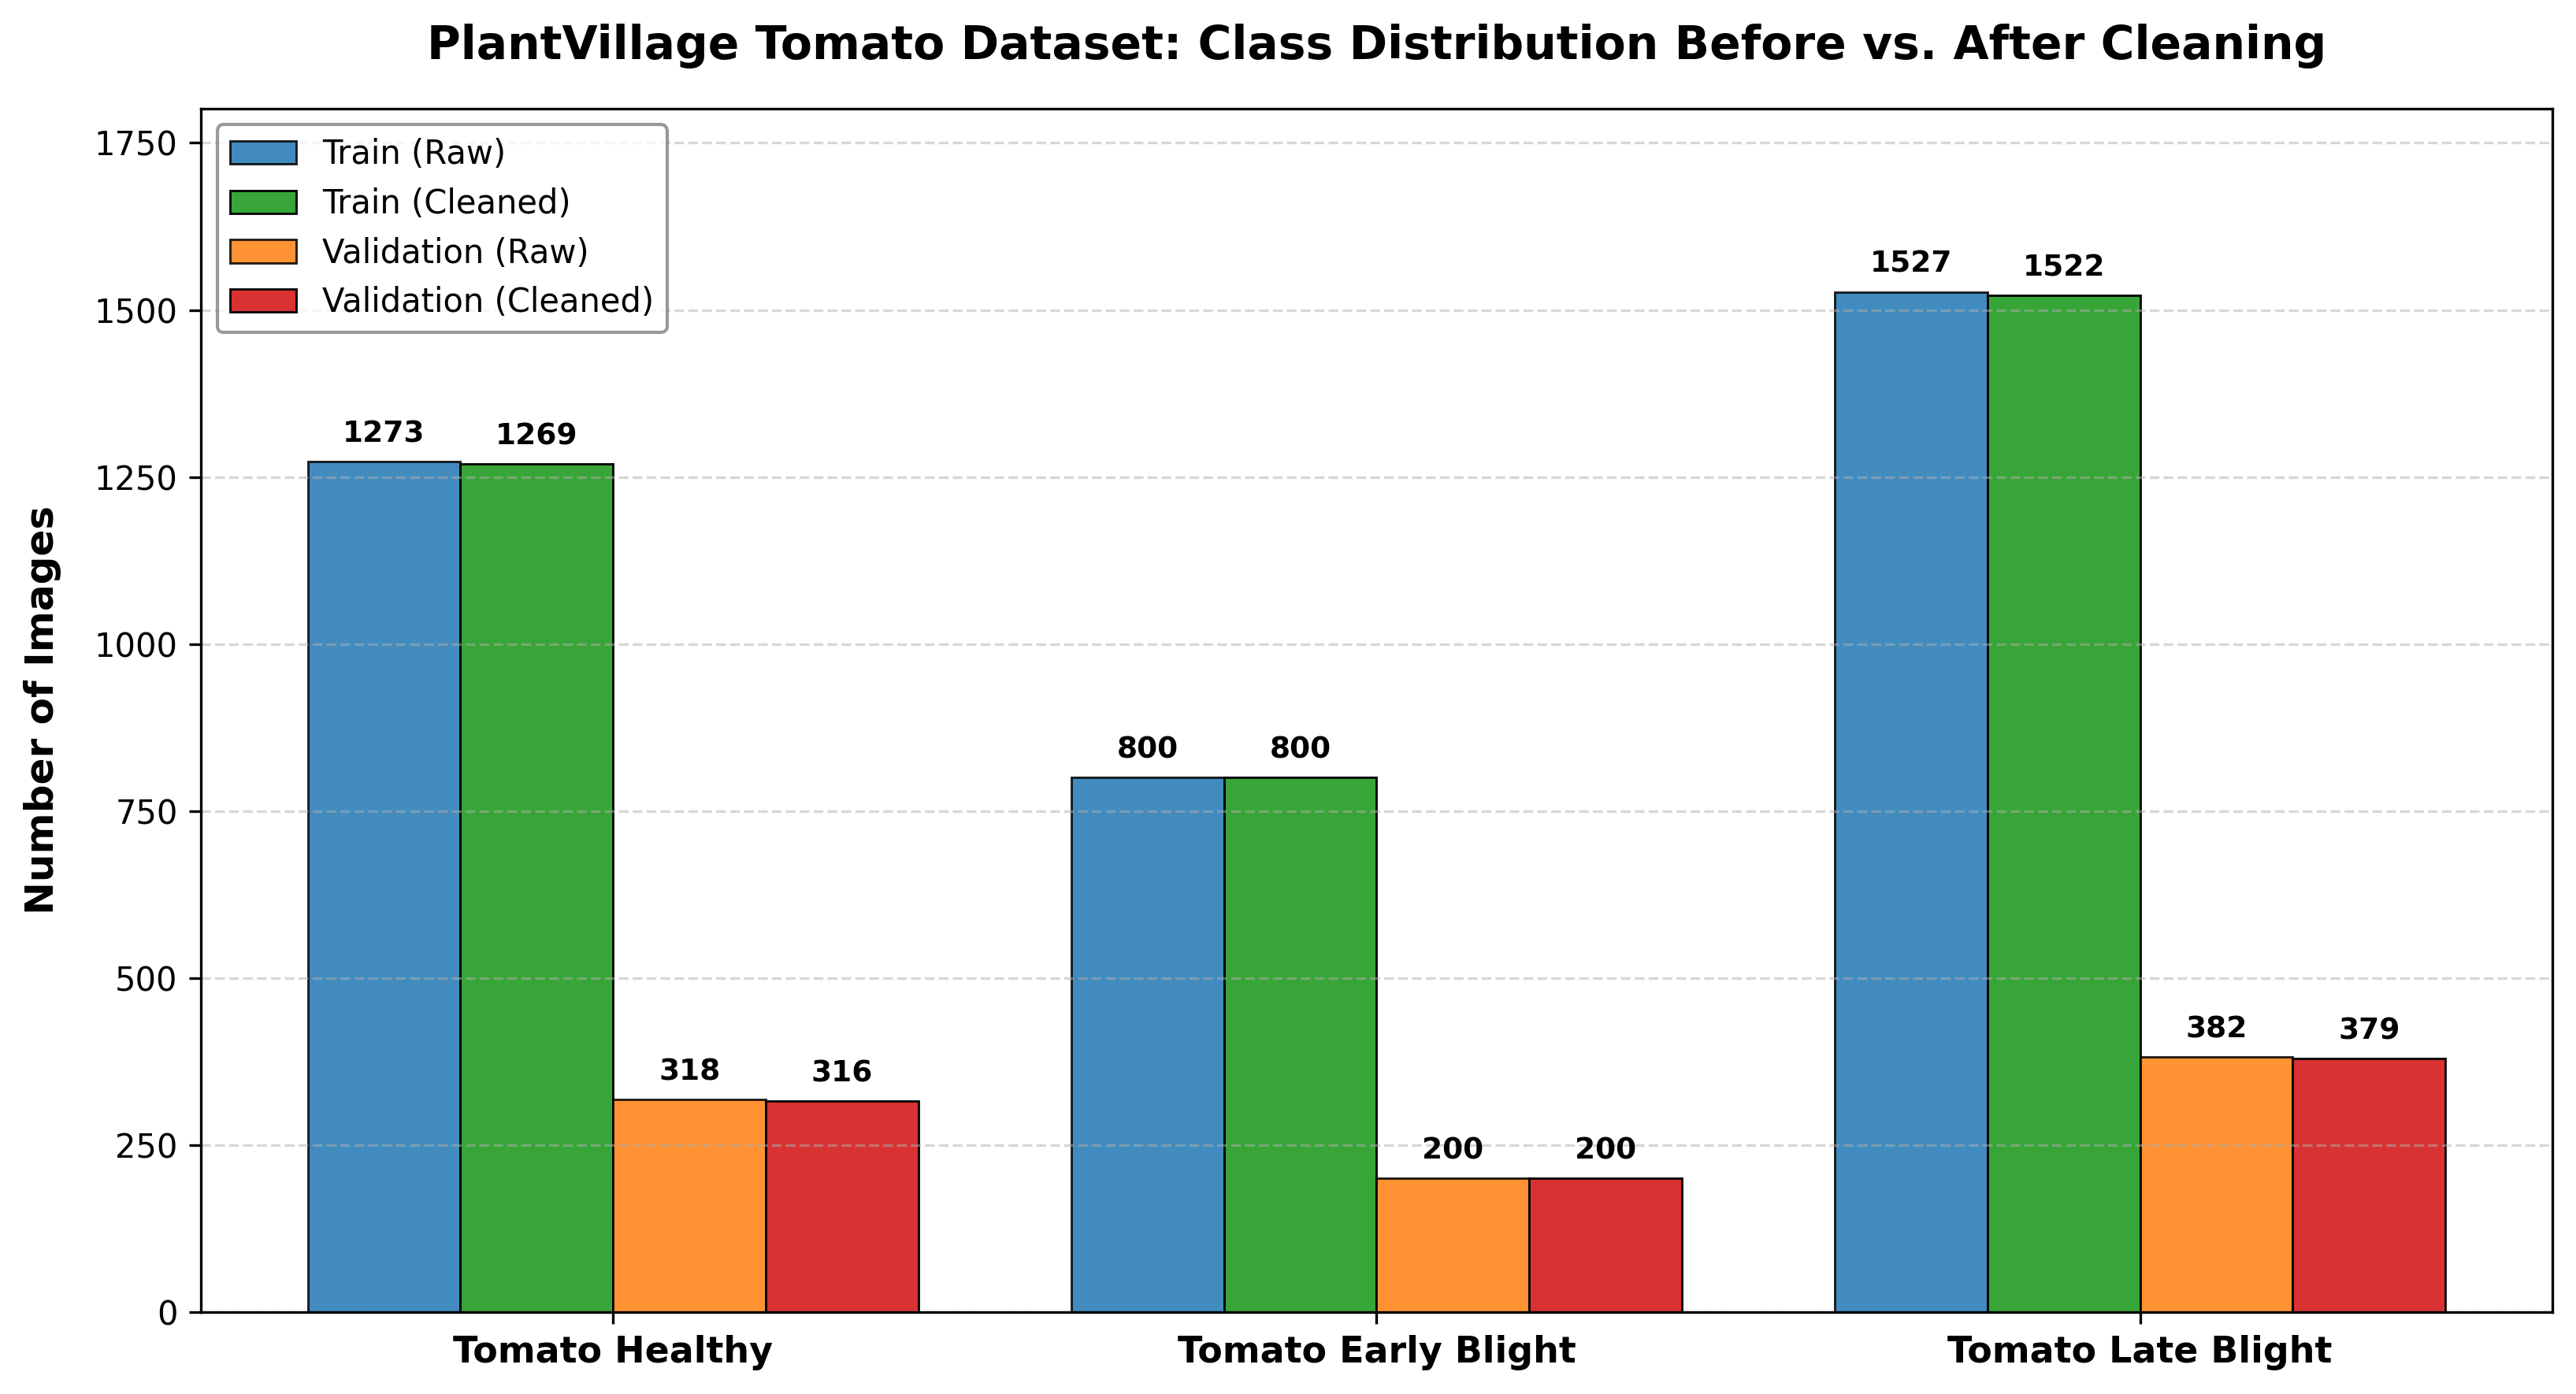

In [38]:
# Generate before-vs-after class distribution chart and save to reports/figures/mahtab/cleaned_class_distribution.png
display_labels = [display_names[cls] for cls in selected_classes]

x = np.arange(len(display_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6), dpi=300)

c_train_raw = "#1f77b4"     # Muted Blue
c_train_clean = "#2ca02c"   # Fresh Green
c_val_raw = "#ff7f0e"       # Coral Orange
c_val_clean = "#d62728"     # Crimson Red

rects1 = ax.bar(x - 1.5*width, cleaned_class_summary_df["Raw Train"], width, label='Train (Raw)', color=c_train_raw, edgecolor='black', linewidth=0.7, alpha=0.85)
rects2 = ax.bar(x - 0.5*width, cleaned_class_summary_df["Cleaned Train"], width, label='Train (Cleaned)', color=c_train_clean, edgecolor='black', linewidth=0.7, alpha=0.95)
rects3 = ax.bar(x + 0.5*width, cleaned_class_summary_df["Raw Val"], width, label='Validation (Raw)', color=c_val_raw, edgecolor='black', linewidth=0.7, alpha=0.85)
rects4 = ax.bar(x + 1.5*width, cleaned_class_summary_df["Cleaned Val"], width, label='Validation (Cleaned)', color=c_val_clean, edgecolor='black', linewidth=0.7, alpha=0.95)

ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('PlantVillage Tomato Dataset: Class Distribution Before vs. After Cleaning', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=11, fontweight='bold')
ax.legend(frameon=True, facecolor='white', edgecolor='gray', fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

def autolabel_small(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h}',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel_small(rects1)
autolabel_small(rects2)
autolabel_small(rects3)
autolabel_small(rects4)

ax.set_ylim(0, cleaned_class_summary_df["Raw Train"].max() * 1.18)
plt.tight_layout()

clean_chart_path = reports_dir / "cleaned_class_distribution.png"
plt.savefig(clean_chart_path, dpi=300, bbox_inches='tight')
print(f"[OK] Before-vs-after class distribution chart saved to:\n  {clean_chart_path.resolve()}")
plt.show()

---
## 9. Data Preparation & Augmentation

In this section, we prepare the cleaned dataset metadata (`clean_train_df` and `clean_val_df`) for rigorous machine learning experiments, build TensorFlow `tf.data` input pipelines, and configure a conservative Keras data augmentation pipeline.

### 9.1 Stratified Train/Validation Split & Test Set Definition

In [39]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# 1. Stratified split of clean_train_df into 80% train and 20% validation
train_df, validation_df = train_test_split(
    clean_train_df,
    test_size=0.20,
    stratify=clean_train_df["class"],
    random_state=SEED
)

# 2. Use clean_val_df as untouched test_df
test_df = clean_val_df.copy()

# 3. Print split sizes
print("=== EXPERIMENTAL DATASET SPLIT SIZES ===")
print(f"[+] Train Set Size      : {len(train_df)} images (80% of cleaned train)")
print(f"[+] Validation Set Size : {len(validation_df)} images (20% of cleaned train)")
print(f"[+] Test Set Size       : {len(test_df)} images (100% of cleaned val)")
print(f"[+] Total Cleaned Images: {len(train_df) + len(validation_df) + len(test_df)}")

# Construct summary split distribution DataFrame
split_summary_data = []
for cls in selected_classes:
    t_cnt = (train_df["class"] == cls).sum()
    v_cnt = (validation_df["class"] == cls).sum()
    test_cnt = (test_df["class"] == cls).sum()
    tot = t_cnt + v_cnt + test_cnt
    split_summary_data.append({
        "Class": cls,
        "Train Count": t_cnt,
        "Train %": round(t_cnt / len(train_df) * 100, 2),
        "Val Count": v_cnt,
        "Val %": round(v_cnt / len(validation_df) * 100, 2),
        "Test Count": test_cnt,
        "Test %": round(test_cnt / len(test_df) * 100, 2),
        "Total": tot
    })

df_split_summary = pd.DataFrame(split_summary_data)
print("\n=== CLASS COUNTS & PERCENTAGES PER SPLIT ===")
display(df_split_summary)

=== EXPERIMENTAL DATASET SPLIT SIZES ===
[+] Train Set Size      : 2872 images (80% of cleaned train)
[+] Validation Set Size : 719 images (20% of cleaned train)
[+] Test Set Size       : 895 images (100% of cleaned val)
[+] Total Cleaned Images: 4486

=== CLASS COUNTS & PERCENTAGES PER SPLIT ===


,Class,Train Count,Train %,Val Count,Val %,Test Count,Test %,Total
0,Tomato___healthy,1015,35.34,254,35.33,316,35.31,1585
1,Tomato___Early_blight,640,22.28,160,22.25,200,22.35,1000
2,Tomato___Late_blight,1217,42.37,305,42.42,379,42.35,1901


### 9.2 Visualization: Train vs Validation vs Test Split Distribution

[OK] Split distribution chart saved to:
  /content/plant-disease-detection/reports/figures/mahtab/split_distribution.png


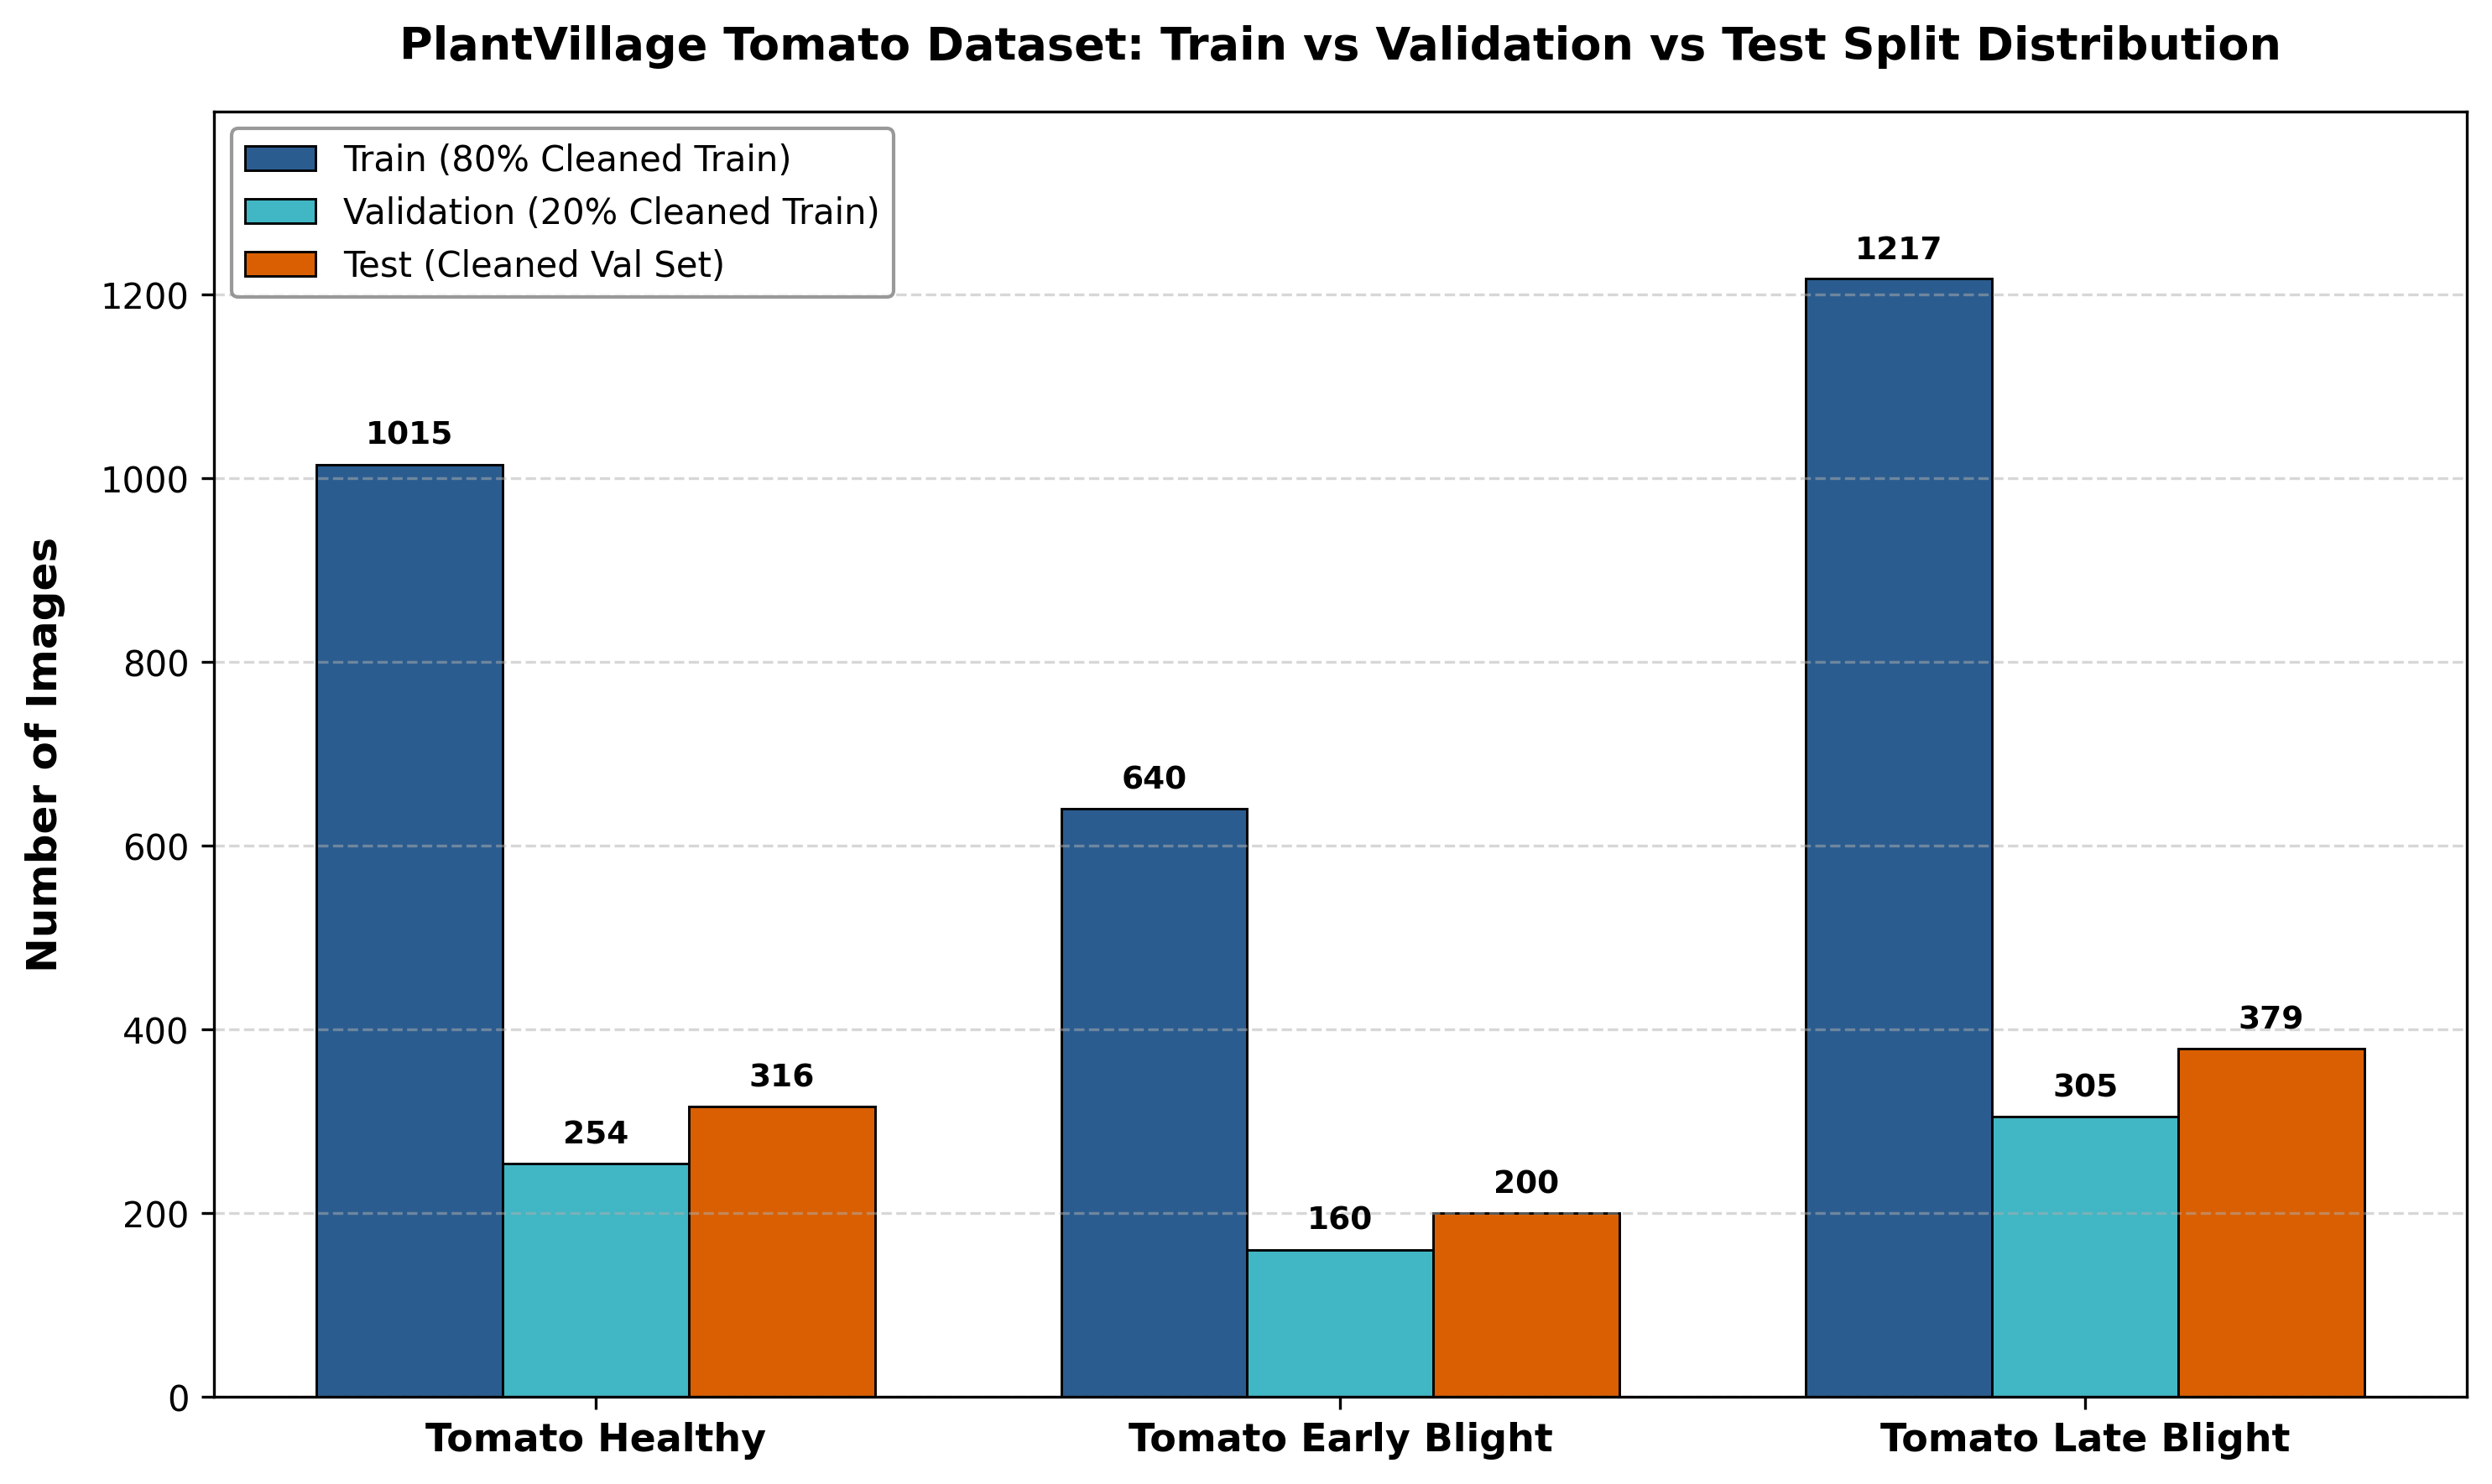

In [40]:
# Generate class distribution chart comparing Train vs Validation vs Test
labels = [display_names[c] for c in selected_classes]
train_counts = train_df["class"].value_counts().reindex(selected_classes).values
val_counts = validation_df["class"].value_counts().reindex(selected_classes).values
test_counts = test_df["class"].value_counts().reindex(selected_classes).values

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

rects1 = ax.bar(x - width, train_counts, width, label='Train (80% Cleaned Train)', color='#2b5c8f', edgecolor='black', linewidth=0.7)
rects2 = ax.bar(x, val_counts, width, label='Validation (20% Cleaned Train)', color='#41b6c4', edgecolor='black', linewidth=0.7)
rects3 = ax.bar(x + width, test_counts, width, label='Test (Cleaned Val Set)', color='#d95f02', edgecolor='black', linewidth=0.7)

ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('PlantVillage Tomato Dataset: Train vs Validation vs Test Split Distribution', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.legend(frameon=True, facecolor='white', edgecolor='gray', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

def autolabel_split(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h}',
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel_split(rects1)
autolabel_split(rects2)
autolabel_split(rects3)

ax.set_ylim(0, max(train_counts) * 1.15)
plt.tight_layout()
split_chart_path = reports_dir / "split_distribution.png"
plt.savefig(split_chart_path, dpi=300, bbox_inches='tight')
print(f"[OK] Split distribution chart saved to:\n  {split_chart_path.resolve()}")
plt.show()

### 9.3 Deterministic Label Mapping & TensorFlow tf.data Pipeline Creation

In [41]:
# 1. Create deterministic label mapping (alphabetically sorted classes -> 0, 1, 2)
label_mapping = {cls: idx for idx, cls in enumerate(sorted(selected_classes))}

print("=== DETERMINISTIC LABEL MAPPING ===")
for cls, idx in label_mapping.items():
    print(f"  [+] Class '{cls}' -> Label ID {idx}")

# Map integer label IDs in DataFrames
train_df["label"] = train_df["class"].map(label_mapping)
validation_df["label"] = validation_df["class"].map(label_mapping)
test_df["label"] = test_df["class"].map(label_mapping)

# 2. Parameters for TensorFlow dataset pipelines
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

# 3. Image loading & decoding function (RGB, resized to 224x224)
def load_and_preprocess_image(filepath, label):
    image_bytes = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, label

# 4. Build tf.data Datasets
# Training dataset: shuffle (seed=42), batch (32), prefetch
train_ds = (
    tf.data.Dataset.from_tensor_slices((train_df["filepath"].values, train_df["label"].values))
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=len(train_df), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=AUTOTUNE)
)

# Validation dataset: no shuffle, batch (32), prefetch
val_ds = (
    tf.data.Dataset.from_tensor_slices((validation_df["filepath"].values, validation_df["label"].values))
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=AUTOTUNE)
)

# Test dataset: no shuffle, batch (32), prefetch
test_ds = (
    tf.data.Dataset.from_tensor_slices((test_df["filepath"].values, test_df["label"].values))
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(buffer_size=AUTOTUNE)
)

print("\n[OK] tf.data Datasets successfully created (train_ds, val_ds, test_ds).")

=== DETERMINISTIC LABEL MAPPING ===
  [+] Class 'Tomato___Early_blight' -> Label ID 0
  [+] Class 'Tomato___Late_blight' -> Label ID 1
  [+] Class 'Tomato___healthy' -> Label ID 2

[OK] tf.data Datasets successfully created (train_ds, val_ds, test_ds).


### 9.4 Reusable Keras Data Augmentation Pipeline & Augmentation Preview

[OK] Keras data_augmentation pipeline initialized.
[OK] Augmentation preview saved to:
  /content/plant-disease-detection/reports/figures/mahtab/augmentation_preview.png


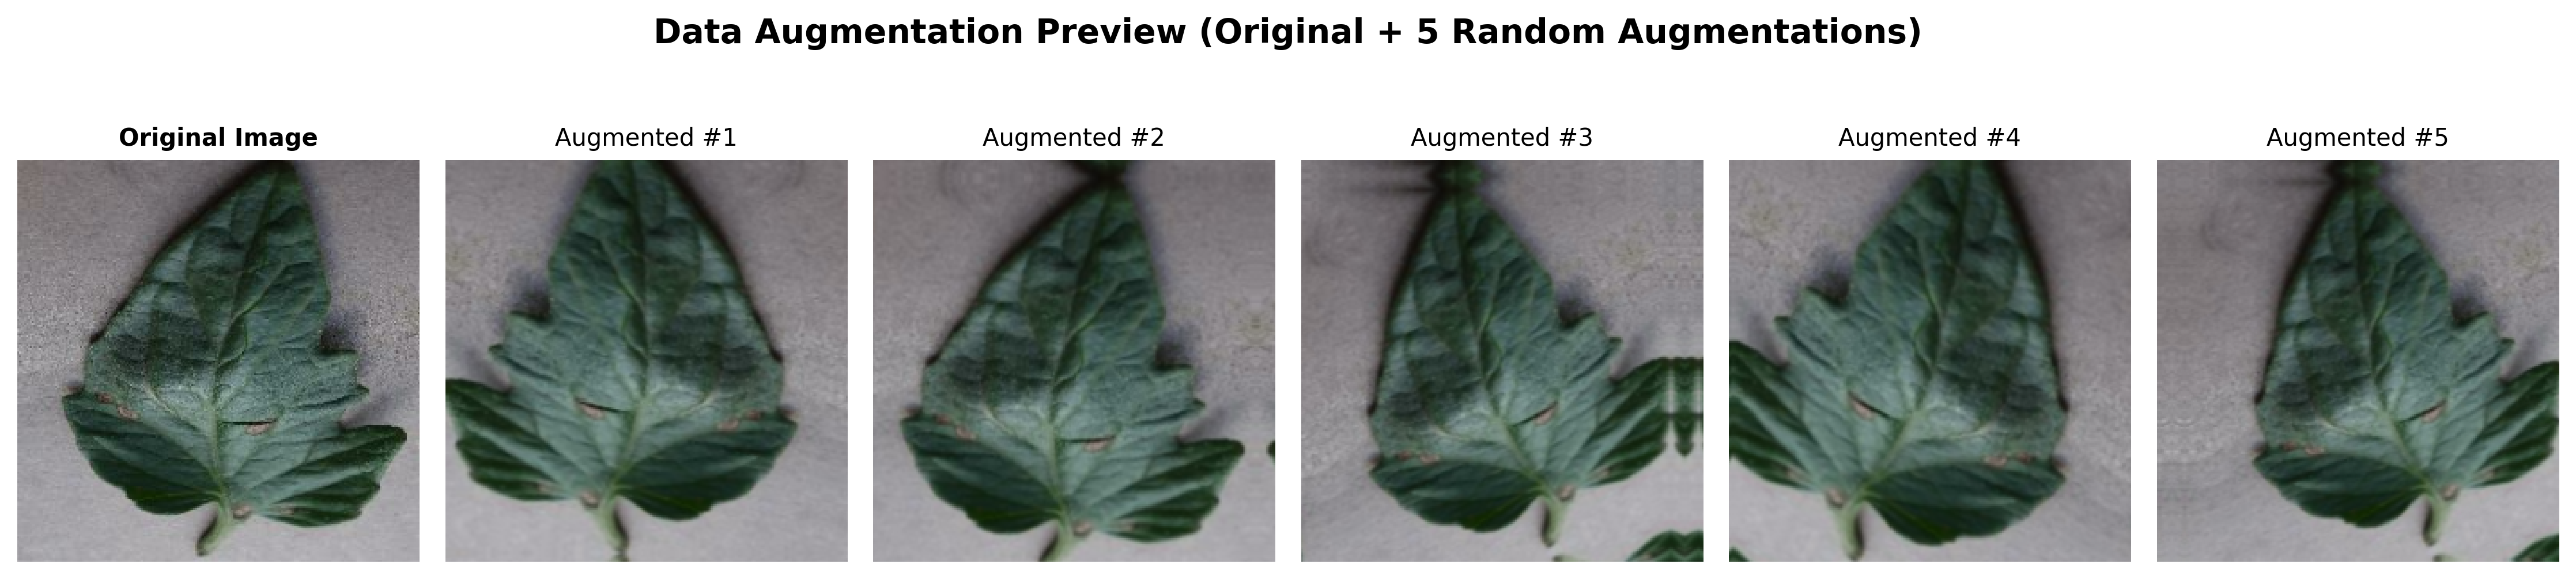

In [42]:
# Reusable conservative data augmentation layer for training
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomRotation(0.08, seed=SEED),
    tf.keras.layers.RandomZoom(0.08, seed=SEED),
    tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05, seed=SEED)
], name="data_augmentation")

print("[OK] Keras data_augmentation pipeline initialized.")

# Generate Augmentation Preview
sample_fpath = train_df.iloc[0]["filepath"]
img_bytes = tf.io.read_file(sample_fpath)
sample_img = tf.image.decode_jpeg(img_bytes, channels=3)
sample_img = tf.image.resize(sample_img, IMAGE_SIZE)
sample_batch = tf.expand_dims(sample_img, 0)

fig, axes = plt.subplots(1, 6, figsize=(15, 3.5), dpi=300)
fig.suptitle('Data Augmentation Preview (Original + 5 Random Augmentations)', fontsize=14, fontweight='bold', y=1.02)

axes[0].imshow(sample_img.numpy().astype("uint8"))
axes[0].set_title("Original Image", fontsize=10, fontweight='bold')
axes[0].axis('off')

tf.random.set_seed(SEED)
for i in range(1, 6):
    aug_img = data_augmentation(sample_batch, training=True)[0]
    axes[i].imshow(aug_img.numpy().astype("uint8"))
    axes[i].set_title(f"Augmented #{i}", fontsize=10, fontweight='medium')
    axes[i].axis('off')

plt.tight_layout()
aug_preview_path = reports_dir / "augmentation_preview.png"
plt.savefig(aug_preview_path, dpi=300, bbox_inches='tight')
print(f"[OK] Augmentation preview saved to:\n  {aug_preview_path.resolve()}")
plt.show()

### 9.5 Dataset Pipeline Sanity Checks

In [43]:
# Run sanity checks on one batch from train_ds
for images_batch, labels_batch in train_ds.take(1):
    print("=== TF.DATA PIPELINE SANITY CHECKS ===")
    print(f"[+] Train Batch Image Shape : {images_batch.shape}")
    print(f"[+] Train Batch Label Shape : {labels_batch.shape}")
    print(f"[+] Image Data Type        : {images_batch.dtype}")
    print(f"[+] Min Pixel Value        : {tf.reduce_min(images_batch).numpy()}")
    print(f"[+] Max Pixel Value        : {tf.reduce_max(images_batch).numpy()}")

    assert images_batch.shape == (32, 224, 224, 3), f"Expected batch shape (32, 224, 224, 3), got {images_batch.shape}"
    assert labels_batch.shape == (32,), f"Expected label shape (32,), got {labels_batch.shape}"
    print("[+] Output Image Size Confirmation: 224 x 224 x 3 [PASSED ALL SANITY CHECKS]")

=== TF.DATA PIPELINE SANITY CHECKS ===
[+] Train Batch Image Shape : (32, 224, 224, 3)
[+] Train Batch Label Shape : (32,)
[+] Image Data Type        : <dtype: 'float32'>
[+] Min Pixel Value        : 0.0
[+] Max Pixel Value        : 254.2090606689453
[+] Output Image Size Confirmation: 224 x 224 x 3 [PASSED ALL SANITY CHECKS]


---
## 10. Transfer Learning Experiment 1 — ResNet50V2 Frozen Feature Extractor

In this experiment, we build and train a transfer learning model using the pre-trained **ResNet50V2** architecture (with ImageNet weights) as a **frozen feature extractor**.

### Experimental Rules & Scope:
- **Datasets Used:** Model is trained on `train_ds` (2,872 images) and validated on `val_ds` (719 images).
- **Test Set Isolation:** `test_ds` (895 images) remains **strictly untouched** until final model selection.
- **Base Model Status:** ResNet50V2 pre-trained feature extractor base is **100% frozen** (`base_model.trainable = False`).
- **Class Imbalance Handling:** Balanced class weights are computed from `train_df` and applied during training.
- **Reproducibility:** Global random seeds (Python, NumPy, TensorFlow) are explicitly set to `42`.

### 10.1 Reproducibility & 10.2 Class Weight Calculation

In [44]:
import random
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

# 10.1 Set seeds for strict reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"[OK] Random seeds set for Python, NumPy, and TensorFlow (SEED = {SEED}).")

# 10.2 Calculate balanced class weights using ONLY train_df
unique_classes = np.unique(train_df["label"].values)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=train_df["label"].values
)
class_weight_dict = dict(zip(unique_classes, class_weights_array))

print("\n=== BALANCED CLASS WEIGHTS (Calculated from train_df) ===")
for cls_name, cls_id in label_mapping.items():
    print(f"  [+] Class '{cls_name}' (ID {cls_id}) -> Weight: {class_weight_dict[cls_id]:.4f}")

[OK] Random seeds set for Python, NumPy, and TensorFlow (SEED = 42).

=== BALANCED CLASS WEIGHTS (Calculated from train_df) ===
  [+] Class 'Tomato___Early_blight' (ID 0) -> Weight: 1.4958
  [+] Class 'Tomato___Late_blight' (ID 1) -> Weight: 0.7866
  [+] Class 'Tomato___healthy' (ID 2) -> Weight: 0.9432


### 10.3 Build ResNet50V2 Transfer Learning Model (Frozen Base)

In [45]:
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input

# 1. Instantiate pretrained ResNet50V2 base without top classification layer
base_model_resnet = ResNet50V2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# 2. Freeze the entire pretrained base model
base_model_resnet.trainable = False

# 3. Construct Functional API pipeline
inputs = tf.keras.Input(shape=(224, 224, 3), name="input_layer")
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model_resnet(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.Dropout(0.30, name="dropout")(x)
outputs = tf.keras.layers.Dense(3, activation="softmax", name="output_layer")(x)

model_resnet_frozen = tf.keras.Model(inputs=inputs, outputs=outputs, name="ResNet50V2_Frozen")

# 4. Print parameter summary and base frozen confirmation
total_params = model_resnet_frozen.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model_resnet_frozen.trainable_weights])
non_trainable_params = sum([tf.keras.backend.count_params(w) for w in model_resnet_frozen.non_trainable_weights])

print("=== RESNET50V2 FROZEN FEATURE EXTRACTOR SUMMARY ===")
print(f"[+] Total Parameters        : {total_params:,}")
print(f"[+] Trainable Parameters    : {trainable_params:,}")
print(f"[+] Non-trainable Parameters: {non_trainable_params:,}")
print(f"[+] Pretrained Base Frozen  : {not base_model_resnet.trainable} (base_model_resnet.trainable = False)")

=== RESNET50V2 FROZEN FEATURE EXTRACTOR SUMMARY ===
[+] Total Parameters        : 23,570,947
[+] Trainable Parameters    : 6,147
[+] Non-trainable Parameters: 23,564,800
[+] Pretrained Base Frozen  : True (base_model_resnet.trainable = False)


### 10.4 Compile Model & 10.5 Callbacks Configuration

In [48]:
# 10.4 Compile model
model_resnet_frozen.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# 10.5 Define training callbacks
early_stopping_resnet = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr_resnet = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

resnet_callbacks = [early_stopping_resnet, reduce_lr_resnet]

print("[OK] ResNet50V2 model compiled with Adam (lr=1e-3).")
print("[OK] Callbacks configured: EarlyStopping (patience=4, restore_best_weights=True) and ReduceLROnPlateau (factor=0.2, patience=2, min_lr=1e-6).")

[OK] ResNet50V2 model compiled with Adam (lr=1e-3).
[OK] Callbacks configured: EarlyStopping (patience=4, restore_best_weights=True) and ReduceLROnPlateau (factor=0.2, patience=2, min_lr=1e-6).


In [49]:
print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

print("\nClass weights:", class_weight_dict)

print("\nBase frozen:", base_model_resnet.trainable == False)
print("Model ready:", model_resnet_frozen is not None)

print("\nGPU:", tf.config.list_physical_devices("GPU"))

Train batches: 90
Validation batches: 23
Test batches: 28

Class weights: {np.int64(0): np.float64(1.4958333333333333), np.int64(1): np.float64(0.7866337989591893), np.int64(2): np.float64(0.9431855500821018)}

Base frozen: True
Model ready: True

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 10.6 Model Training (Max 15 Epochs)

In [50]:
# Train on train_ds, validate on val_ds (max 15 epochs, class weights applied)
MAX_EPOCHS = 15

history_resnet_frozen = model_resnet_frozen.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=resnet_callbacks
)

Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 197ms/step - accuracy: 0.7026 - loss: 0.7055 - val_accuracy: 0.8734 - val_loss: 0.3259 - learning_rate: 0.0010
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 35s 158ms/step - accuracy: 0.8785 - loss: 0.3137 - val_accuracy: 0.9152 - val_loss: 0.2383 - learning_rate: 0.0010
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.8966 - loss: 0.2610 - val_accuracy: 0.9207 - val_loss: 0.2166 - learning_rate: 0.0010
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 172ms/step - accuracy: 0.9116 - loss: 0.2285 - val_accuracy: 0.9388 - val_loss: 0.1858 - learning_rate: 0.0010
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 164ms/step - accuracy: 0.9199 - loss: 0.2030 - val_accuracy: 0.9374 - val_loss: 0.1749 - learning_rate: 0.0010
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 17s 160ms/step - accuracy: 0.9304 - loss: 0.1862 - val_accuracy: 0.9388 - val_loss: 0.1739 - learning_rate: 0.0010
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 161ms/step - accuracy: 0.9401 - loss: 0.

### 10.7 Training & Validation Curves

[OK] Training curves figure saved to:
  /content/plant-disease-detection/reports/figures/mahtab/resnet50v2_frozen_training_curves.png


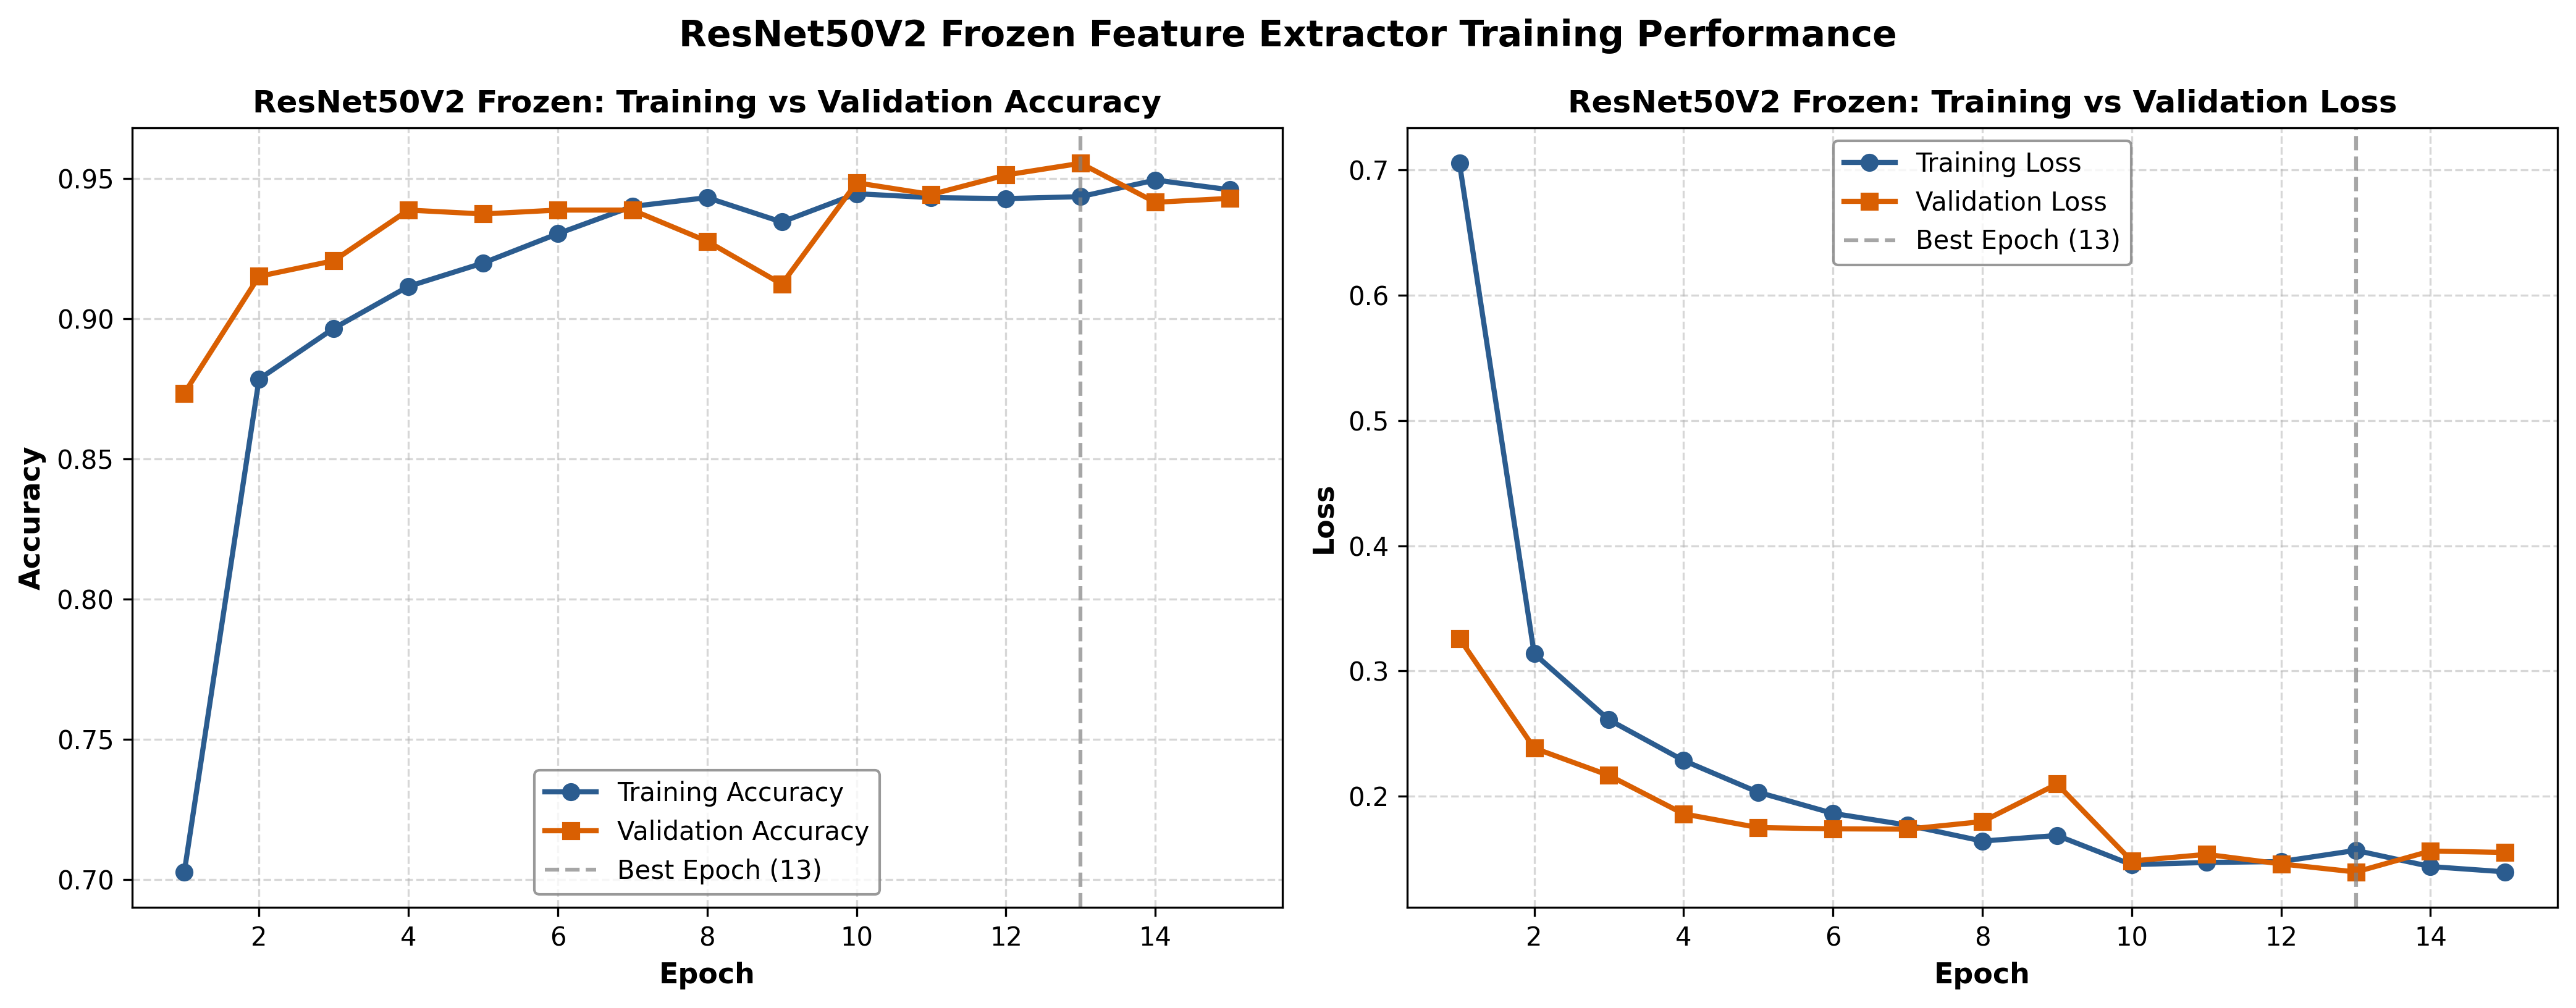

In [51]:
# Plot Accuracy & Loss training curves and mark best validation epoch
hist = history_resnet_frozen.history
epochs_range = range(1, len(hist["loss"]) + 1)
best_epoch = np.argmin(hist["val_loss"]) + 1
best_val_loss = hist["val_loss"][best_epoch - 1]
best_val_acc = hist["val_accuracy"][best_epoch - 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)

# Accuracy plot
ax1.plot(epochs_range, hist["accuracy"], 'o-', label='Training Accuracy', color='#2b5c8f', linewidth=2)
ax1.plot(epochs_range, hist["val_accuracy"], 's-', label='Validation Accuracy', color='#d95f02', linewidth=2)
ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('ResNet50V2 Frozen: Training vs Validation Accuracy', fontsize=12, fontweight='bold')
ax1.legend(frameon=True, facecolor='white', edgecolor='gray')
ax1.grid(True, linestyle='--', alpha=0.5)

# Loss plot
ax2.plot(epochs_range, hist["loss"], 'o-', label='Training Loss', color='#2b5c8f', linewidth=2)
ax2.plot(epochs_range, hist["val_loss"], 's-', label='Validation Loss', color='#d95f02', linewidth=2)
ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax2.set_title('ResNet50V2 Frozen: Training vs Validation Loss', fontsize=12, fontweight='bold')
ax2.legend(frameon=True, facecolor='white', edgecolor='gray')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('ResNet50V2 Frozen Feature Extractor Training Performance', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

curves_path = reports_dir / "resnet50v2_frozen_training_curves.png"
plt.savefig(curves_path, dpi=300, bbox_inches='tight')
print(f"[OK] Training curves figure saved to:\n  {curves_path.resolve()}")
plt.show()

### 10.8 Validation Set Evaluation & Confusion Matrix

=== VALIDATION CLASSIFICATION REPORT ===


,precision,recall,f1-score,support
Early Blight,0.9125,0.9125,0.9125,160.0000
Late Blight,0.9729,0.9410,0.9567,305.0000
Healthy,0.9621,1.0000,0.9807,254.0000
accuracy,0.9555,0.9555,0.9555,0.9555
macro avg,0.9492,0.9512,0.9500,719.0000
weighted avg,0.9556,0.9555,0.9553,719.0000


[OK] Confusion matrix figure saved to:
  /content/plant-disease-detection/reports/figures/mahtab/resnet50v2_frozen_confusion_matrix.png


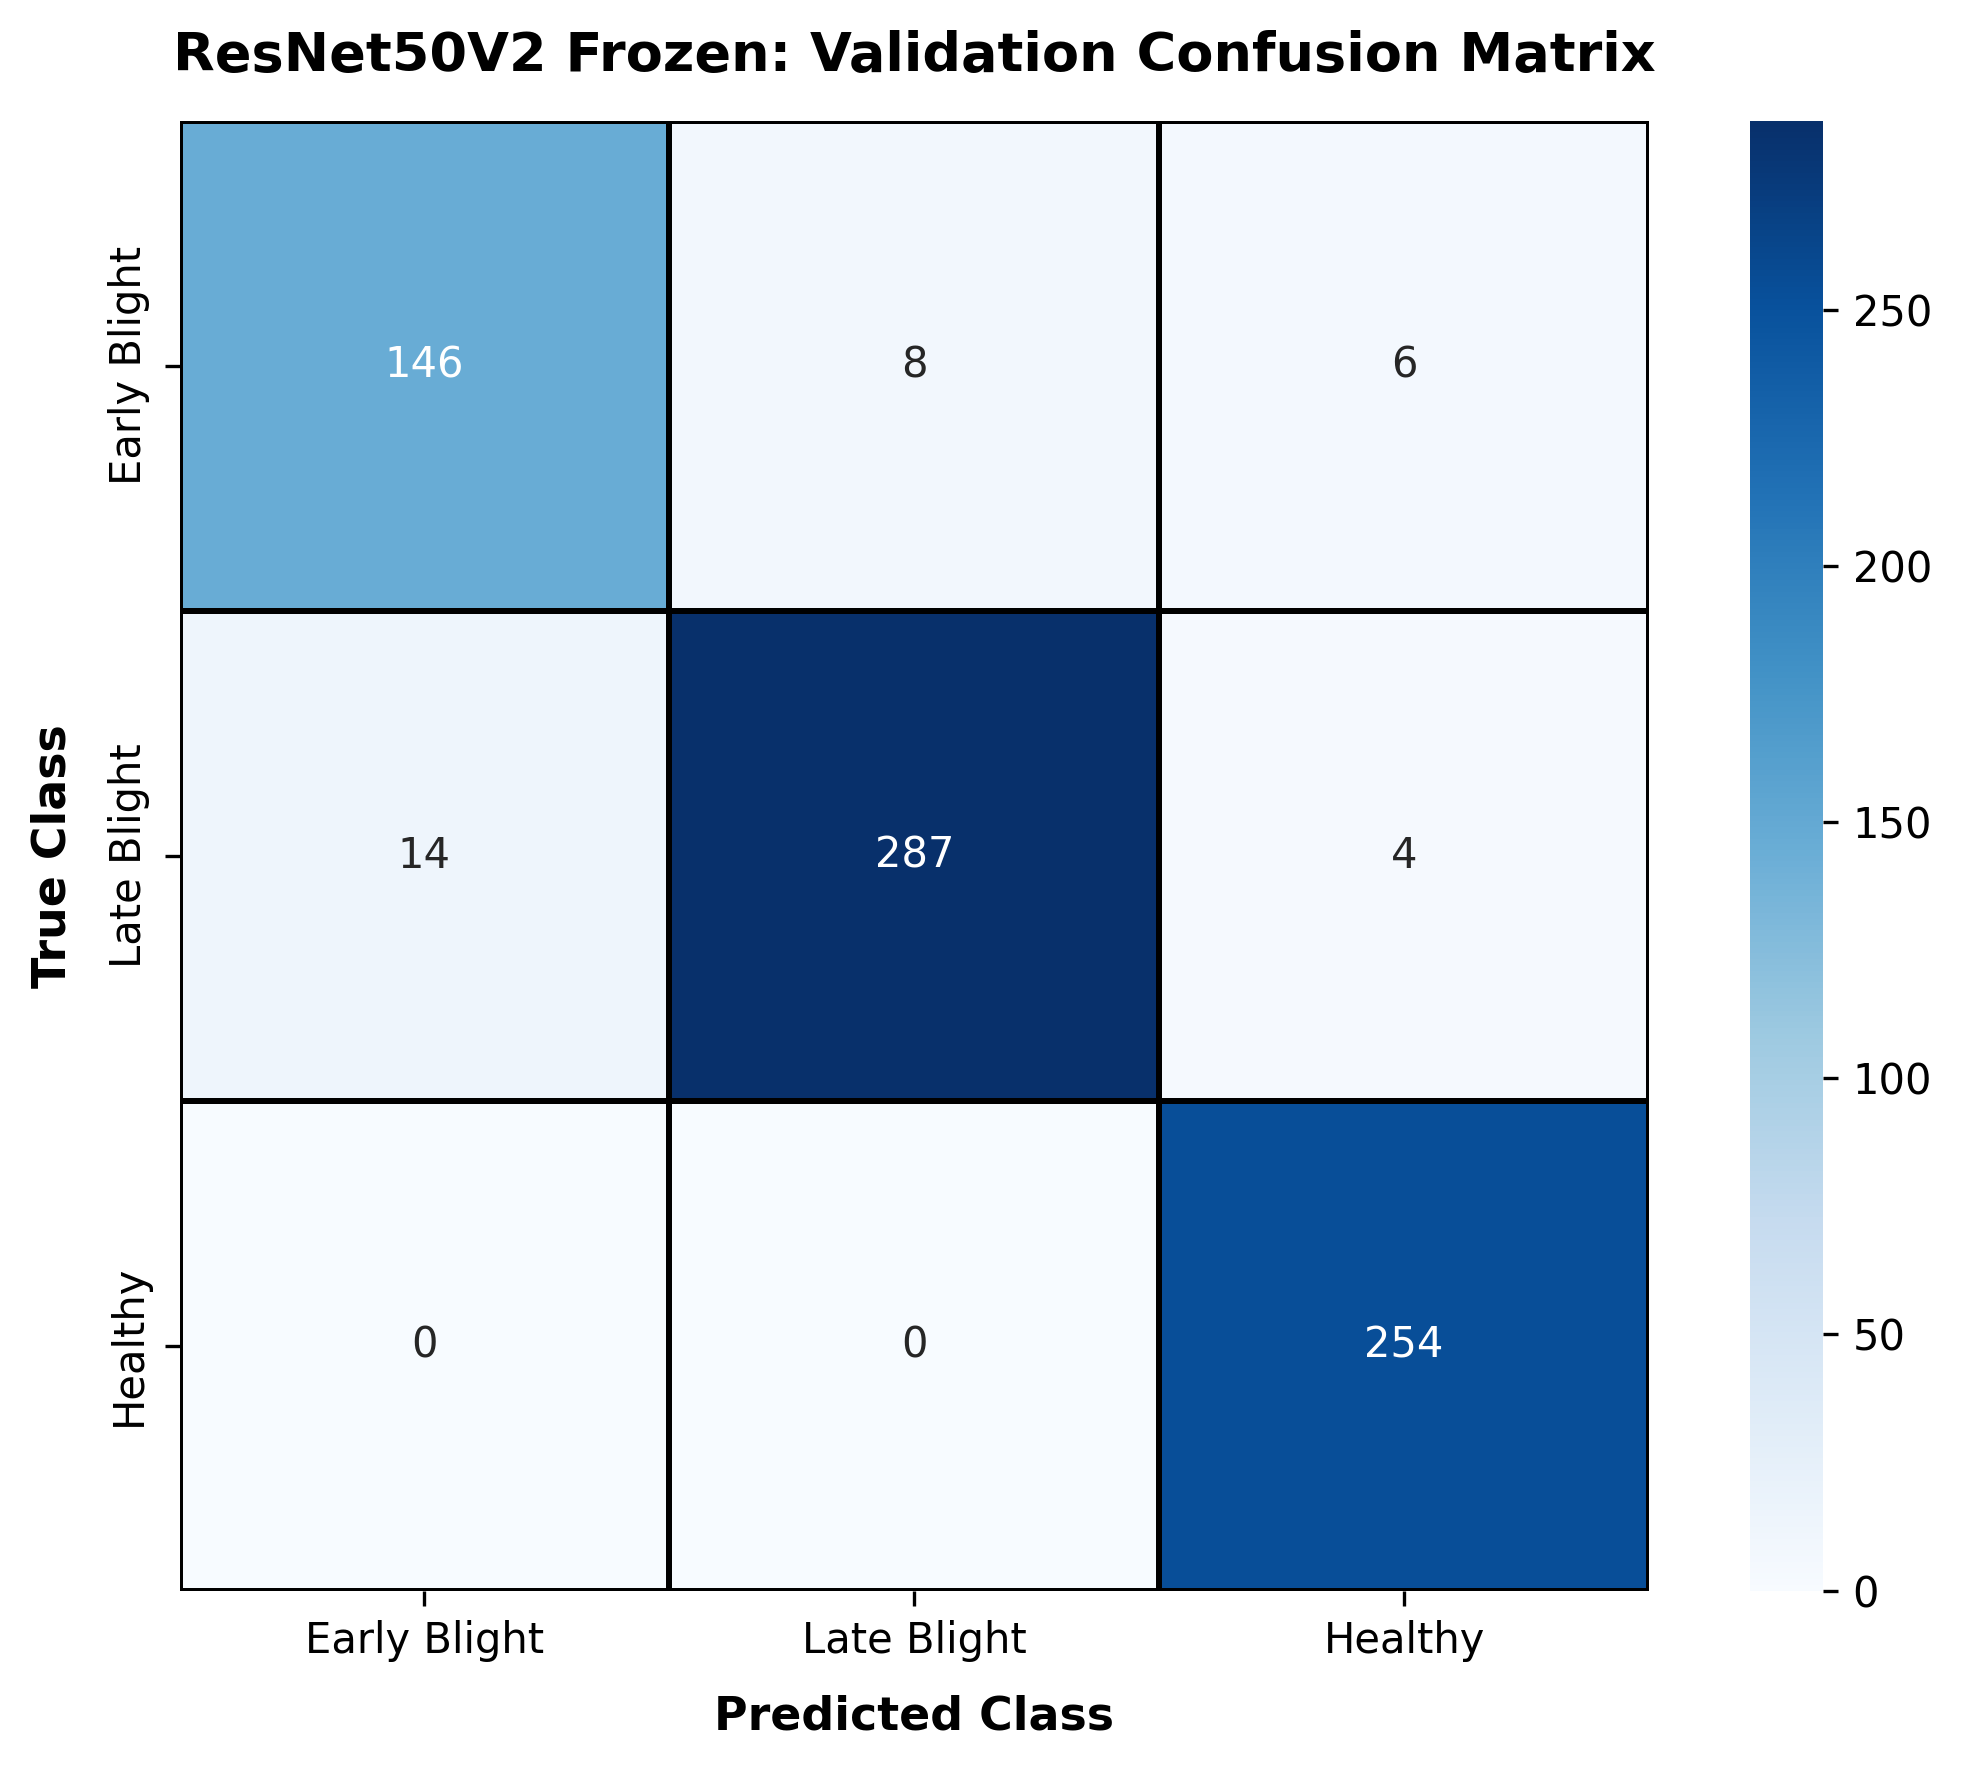

In [52]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# 1. Evaluate on val_ds
eval_results = model_resnet_frozen.evaluate(val_ds, verbose=0)
val_loss_eval, val_acc_eval = eval_results[0], eval_results[1]

# 2. Generate predictions on val_ds (without shuffling)
y_val_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
y_val_pred_probs = model_resnet_frozen.predict(val_ds, verbose=0)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)

# Human-readable class names ordered by label ID (0, 1, 2)
class_names_human = ["Early Blight", "Late Blight", "Healthy"]

# 3. Compute classification report DataFrame
report_dict = classification_report(
    y_val_true,
    y_val_pred,
    target_names=class_names_human,
    output_dict=True
)
df_classification_report = pd.DataFrame(report_dict).transpose().round(4)

print("=== VALIDATION CLASSIFICATION REPORT ===")
display(df_classification_report)

# 4. Plot & save confusion matrix
cm = confusion_matrix(y_val_true, y_val_pred)

fig, ax = plt.subplots(figsize=(7.5, 6), dpi=300)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_human,
    yticklabels=class_names_human,
    cbar=True,
    square=True,
    linewidths=1,
    linecolor="black",
    ax=ax
)

ax.set_xlabel('Predicted Class', fontsize=11, fontweight='bold', labelpad=8)
ax.set_ylabel('True Class', fontsize=11, fontweight='bold', labelpad=8)
ax.set_title('ResNet50V2 Frozen: Validation Confusion Matrix', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
cm_path = reports_dir / "resnet50v2_frozen_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"[OK] Confusion matrix figure saved to:\n  {cm_path.resolve()}")
plt.show()

### 10.9 Validation Result Summary

In [53]:
# Compute macro & weighted metrics
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_val_true, y_val_pred, average="macro")
p_weight, r_weight, f1_weighted, _ = precision_recall_fscore_support(y_val_true, y_val_pred, average="weighted")

print("=== RESNET50V2 FROZEN EXPERIMENT SUMMARY ===")
print(f"[+] Best Validation Epoch          : {best_epoch} / {len(hist['loss'])}")
print(f"[+] Best Validation Accuracy       : {best_val_acc * 100:.2f}%")
print(f"[+] Restored Validation Accuracy   : {val_acc_eval * 100:.2f}% (Loss: {val_loss_eval:.4f})")
print(f"[+] Macro F1-Score                 : {f1_macro:.4f}")
print(f"[+] Weighted F1-Score              : {f1_weighted:.4f}")

=== RESNET50V2 FROZEN EXPERIMENT SUMMARY ===
[+] Best Validation Epoch          : 13 / 15
[+] Best Validation Accuracy       : 95.55%
[+] Restored Validation Accuracy   : 95.55% (Loss: 0.1394)
[+] Macro F1-Score                 : 0.9500
[+] Weighted F1-Score              : 0.9553


ResNet50V2 Fine-Tuning

In [54]:
# Preserve the best frozen-model weights before fine-tuning
frozen_weights_path = "/content/resnet50v2_frozen_best.weights.h5"
model_resnet_frozen.save_weights(frozen_weights_path)

print("[OK] Frozen ResNet50V2 weights saved before fine-tuning.")

[OK] Frozen ResNet50V2 weights saved before fine-tuning.


In [58]:
from tensorflow.keras.layers import BatchNormalization

# Reset fine-tuning configuration
base_model_resnet.trainable = True

# Freeze every layer first
for layer in base_model_resnet.layers:
    layer.trainable = False

# Unfreeze only the final ResNet50V2 residual block
for layer in base_model_resnet.layers:
    if layer.name.startswith("conv5_block3"):
        if not isinstance(layer, BatchNormalization):
            layer.trainable = True

# Keep using the already trained frozen model
model_resnet_finetuned = model_resnet_frozen

trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in model_resnet_finetuned.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(w)
    for w in model_resnet_finetuned.non_trainable_weights
)

print("=== RESNET50V2 CONTROLLED FINE-TUNING SETUP ===")
print("Trainable parameters    :", f"{trainable_params:,}")
print("Non-trainable parameters:", f"{non_trainable_params:,}")

print("\nTrainable base layers:")
for layer in base_model_resnet.layers:
    if layer.trainable:
        print(" -", layer.name)

=== RESNET50V2 CONTROLLED FINE-TUNING SETUP ===
Trainable parameters    : 4,464,643
Non-trainable parameters: 19,106,304

Trainable base layers:
 - conv5_block3_preact_relu
 - conv5_block3_1_conv
 - conv5_block3_1_relu
 - conv5_block3_2_pad
 - conv5_block3_2_conv
 - conv5_block3_2_relu
 - conv5_block3_3_conv
 - conv5_block3_out


In [62]:
model_resnet_finetuned.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("[OK] Fine-tuning model compiled with Adam (lr=1e-5).")

[OK] Fine-tuning model compiled with Adam (lr=1e-5).


In [63]:
fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("[OK] Fine-tuning callbacks configured.")

[OK] Fine-tuning callbacks configured.


In [64]:
FINE_TUNE_EPOCHS = 10

history_resnet_finetuned = model_resnet_finetuned.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=fine_tune_callbacks
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 33s 218ms/step - accuracy: 0.9544 - loss: 0.1281 - val_accuracy: 0.9444 - val_loss: 0.1391 - learning_rate: 1.0000e-05
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 38s 177ms/step - accuracy: 0.9523 - loss: 0.1234 - val_accuracy: 0.9569 - val_loss: 0.1231 - learning_rate: 1.0000e-05
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 176ms/step - accuracy: 0.9596 - loss: 0.1080 - val_accuracy: 0.9541 - val_loss: 0.1257 - learning_rate: 1.0000e-05
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 178ms/step - accuracy: 0.9641 - loss: 0.0958 - val_accuracy: 0.9597 - val_loss: 0.1209 - learning_rate: 1.0000e-05
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 170ms/step - accuracy: 0.9701 - loss: 0.0832 - val_accuracy: 0.9541 - val_loss: 0.1335 - learning_rate: 1.0000e-05
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.9735 - loss: 0.0722 - val_accuracy: 0.9638 - val_loss: 0.1058 - learning_rate: 1.0000e-05
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 172ms/step - acc

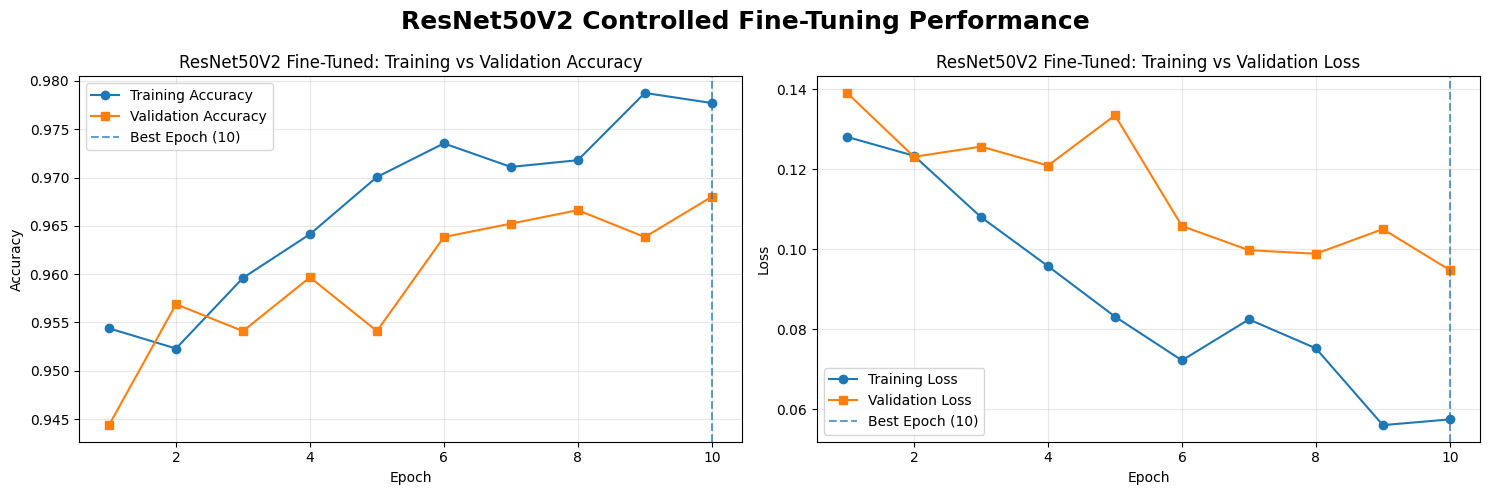

[OK] Saved: /content/plant-disease-detection/reports/figures/mahtab/resnet50v2_finetuned_training_curves.png


In [65]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

hist_ft = history_resnet_finetuned.history
epochs_ft = range(1, len(hist_ft["loss"]) + 1)

best_ft_epoch = int(np.argmin(hist_ft["val_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(epochs_ft, hist_ft["accuracy"], marker="o", label="Training Accuracy")
axes[0].plot(epochs_ft, hist_ft["val_accuracy"], marker="s", label="Validation Accuracy")
axes[0].axvline(best_ft_epoch, linestyle="--", alpha=0.7,
                label=f"Best Epoch ({best_ft_epoch})")
axes[0].set_title("ResNet50V2 Fine-Tuned: Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(epochs_ft, hist_ft["loss"], marker="o", label="Training Loss")
axes[1].plot(epochs_ft, hist_ft["val_loss"], marker="s", label="Validation Loss")
axes[1].axvline(best_ft_epoch, linestyle="--", alpha=0.7,
                label=f"Best Epoch ({best_ft_epoch})")
axes[1].set_title("ResNet50V2 Fine-Tuned: Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(
    "ResNet50V2 Controlled Fine-Tuning Performance",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

figure_dir = Path("/content/plant-disease-detection/reports/figures/mahtab")
figure_dir.mkdir(parents=True, exist_ok=True)

ft_curve_path = figure_dir / "resnet50v2_finetuned_training_curves.png"
plt.savefig(ft_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("[OK] Saved:", ft_curve_path)

In [66]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
import pandas as pd
import numpy as np

# Evaluate on validation ONLY
ft_val_loss, ft_val_accuracy = model_resnet_finetuned.evaluate(
    val_ds,
    verbose=1
)

# Predictions
ft_val_prob = model_resnet_finetuned.predict(val_ds, verbose=1)
ft_val_pred = np.argmax(ft_val_prob, axis=1)

# True labels
ft_val_true = np.concatenate(
    [labels.numpy() for _, labels in val_ds]
)

class_names = [
    "Early Blight",
    "Late Blight",
    "Healthy"
]

report_ft = classification_report(
    ft_val_true,
    ft_val_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_ft_df = pd.DataFrame(report_ft).T
display(report_ft_df.round(4))

p_macro_ft, r_macro_ft, f1_macro_ft, _ = precision_recall_fscore_support(
    ft_val_true,
    ft_val_pred,
    average="macro",
    zero_division=0
)

_, _, f1_weighted_ft, _ = precision_recall_fscore_support(
    ft_val_true,
    ft_val_pred,
    average="weighted",
    zero_division=0
)

print("\n=== RESNET50V2 FINE-TUNED VALIDATION SUMMARY ===")
print(f"Validation Accuracy : {ft_val_accuracy * 100:.2f}%")
print(f"Validation Loss     : {ft_val_loss:.4f}")
print(f"Macro Precision     : {p_macro_ft:.4f}")
print(f"Macro Recall        : {r_macro_ft:.4f}")
print(f"Macro F1            : {f1_macro_ft:.4f}")
print(f"Weighted F1         : {f1_weighted_ft:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.9680 - loss: 0.0948
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step


,precision,recall,f1-score,support
Early Blight,0.9371,0.9312,0.9342,160.000
Late Blight,0.9767,0.9607,0.9686,305.000
Healthy,0.9769,1.0000,0.9883,254.000
accuracy,0.9680,0.9680,0.9680,0.968
macro avg,0.9636,0.9640,0.9637,719.000
weighted avg,0.9680,0.9680,0.9679,719.000



=== RESNET50V2 FINE-TUNED VALIDATION SUMMARY ===
Validation Accuracy : 96.80%
Validation Loss     : 0.0948
Macro Precision     : 0.9636
Macro Recall        : 0.9640
Macro F1            : 0.9637
Weighted F1         : 0.9679


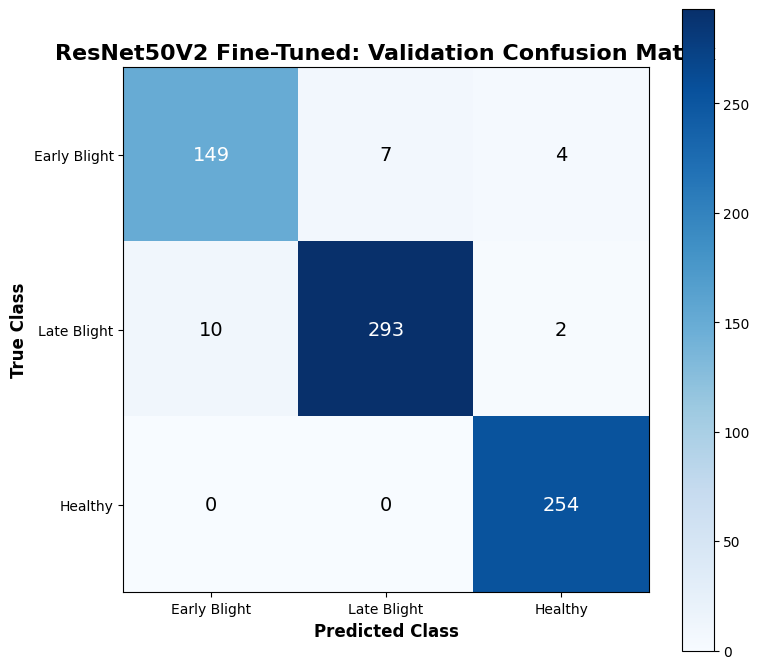

[OK] Saved: /content/plant-disease-detection/reports/figures/mahtab/resnet50v2_finetuned_confusion_matrix.png


In [67]:
import matplotlib.pyplot as plt
import numpy as np

cm_ft = confusion_matrix(ft_val_true, ft_val_pred)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm_ft, cmap="Blues")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Class", fontsize=12, fontweight="bold")
ax.set_ylabel("True Class", fontsize=12, fontweight="bold")
ax.set_title(
    "ResNet50V2 Fine-Tuned: Validation Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

for i in range(cm_ft.shape[0]):
    for j in range(cm_ft.shape[1]):
        ax.text(
            j, i, cm_ft[i, j],
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm_ft[i, j] > cm_ft.max() / 2 else "black"
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()

cm_path = figure_dir / "resnet50v2_finetuned_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("[OK] Saved:", cm_path)

In [68]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [69]:
from pathlib import Path

model_backup_dir = Path(
    "/content/drive/MyDrive/plant-disease-detection-models"
)
model_backup_dir.mkdir(parents=True, exist_ok=True)

finetuned_weights_path = (
    model_backup_dir / "resnet50v2_finetuned_best.weights.h5"
)

model_resnet_finetuned.save_weights(finetuned_weights_path)

print("[OK] Fine-tuned weights saved to:")
print(finetuned_weights_path)

[OK] Fine-tuned weights saved to:
/content/drive/MyDrive/plant-disease-detection-models/resnet50v2_finetuned_best.weights.h5


In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comparison_df = pd.DataFrame({
    "Model": [
        "ResNet50V2 Frozen",
        "ResNet50V2 Fine-Tuned"
    ],
    "Validation Accuracy": [
        0.9555,
        ft_val_accuracy
    ],
    "Macro F1": [
        0.9500,
        f1_macro_ft
    ],
    "Weighted F1": [
        0.9553,
        f1_weighted_ft
    ],
    "Validation Loss": [
        0.1394,
        ft_val_loss
    ]
})

display(comparison_df.round(4))

,Model,Validation Accuracy,Macro F1,Weighted F1,Validation Loss
0,ResNet50V2 Frozen,0.9555,0.9500,0.9553,0.1394
1,ResNet50V2 Fine-Tuned,0.9680,0.9637,0.9679,0.0948


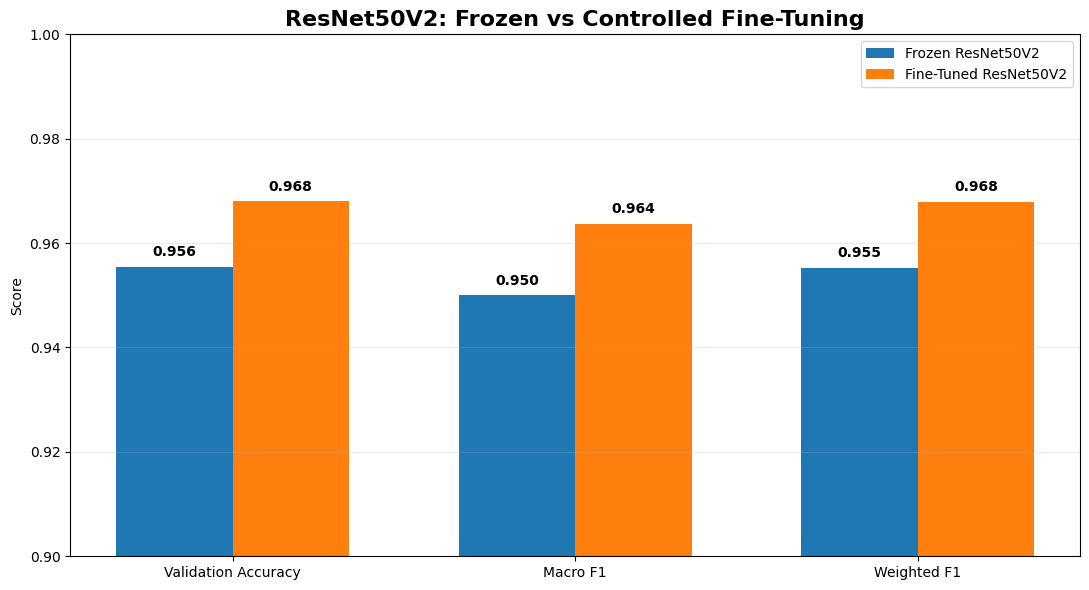

[OK] Saved: /content/plant-disease-detection/reports/figures/mahtab/resnet50v2_frozen_vs_finetuned_comparison.png


In [71]:
metrics = [
    "Validation Accuracy",
    "Macro F1",
    "Weighted F1"
]

x = np.arange(len(metrics))
width = 0.34

frozen_values = comparison_df.loc[0, metrics].values.astype(float)
finetuned_values = comparison_df.loc[1, metrics].values.astype(float)

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width/2,
    frozen_values,
    width,
    label="Frozen ResNet50V2"
)

bars2 = ax.bar(
    x + width/2,
    finetuned_values,
    width,
    label="Fine-Tuned ResNet50V2"
)

ax.set_ylabel("Score")
ax.set_title(
    "ResNet50V2: Frozen vs Controlled Fine-Tuning",
    fontsize=16,
    fontweight="bold"
)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.90, 1.00)
ax.legend()
ax.grid(axis="y", alpha=0.25)

for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            value + 0.002,
            f"{value:.3f}",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()

comparison_path = (
    figure_dir /
    "resnet50v2_frozen_vs_finetuned_comparison.png"
)

plt.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("[OK] Saved:", comparison_path)

## Experiment 3 — EfficientNetB0 Frozen Feature Extractor

In [72]:
import tensorflow as tf
from tensorflow.keras import layers, Model

tf.keras.utils.set_random_seed(42)

base_model_effnet = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_effnet.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# EfficientNetB0 includes its own input rescaling/preprocessing
x = base_model_effnet(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    3,
    activation="softmax"
)(x)

model_effnet_frozen = Model(
    inputs,
    outputs,
    name="EfficientNetB0_Frozen"
)

trainable_params_eff = sum(
    tf.keras.backend.count_params(w)
    for w in model_effnet_frozen.trainable_weights
)

non_trainable_params_eff = sum(
    tf.keras.backend.count_params(w)
    for w in model_effnet_frozen.non_trainable_weights
)

print("=== EFFICIENTNETB0 FROZEN FEATURE EXTRACTOR ===")
print("Trainable parameters    :", f"{trainable_params_eff:,}")
print("Non-trainable parameters:", f"{non_trainable_params_eff:,}")
print("Base model frozen       :", base_model_effnet.trainable == False)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== EFFICIENTNETB0 FROZEN FEATURE EXTRACTOR ===
Trainable parameters    : 3,843
Non-trainable parameters: 4,049,571.0
Base model frozen       : True


In [73]:
model_effnet_frozen.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("[OK] EfficientNetB0 frozen model compiled.")

[OK] EfficientNetB0 frozen model compiled.


In [74]:
effnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("[OK] EfficientNetB0 callbacks configured.")

[OK] EfficientNetB0 callbacks configured.


In [75]:
EFFNET_MAX_EPOCHS = 15

history_effnet_frozen = model_effnet_frozen.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EFFNET_MAX_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=effnet_callbacks
)

Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 34s 143ms/step - accuracy: 0.7514 - loss: 0.6354 - val_accuracy: 0.8707 - val_loss: 0.3790 - learning_rate: 0.0010
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.8959 - loss: 0.3411 - val_accuracy: 0.9013 - val_loss: 0.2901 - learning_rate: 0.0010
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.9224 - loss: 0.2603 - val_accuracy: 0.9082 - val_loss: 0.2489 - learning_rate: 0.0010
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.9328 - loss: 0.2266 - val_accuracy: 0.9305 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.9318 - loss: 0.2040 - val_accuracy: 0.9430 - val_loss: 0.1780 - learning_rate: 0.0010
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.9439 - loss: 0.1890 - val_accuracy: 0.9458 - val_loss: 0.1745 - learning_rate: 0.0010
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.9488 - loss: 0.1

In [76]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
import pandas as pd
import numpy as np

# Evaluate ONLY on validation data
eff_val_loss, eff_val_accuracy = model_effnet_frozen.evaluate(
    val_ds,
    verbose=1
)

# Predictions
eff_val_prob = model_effnet_frozen.predict(val_ds, verbose=1)
eff_val_pred = np.argmax(eff_val_prob, axis=1)

# True labels
eff_val_true = np.concatenate(
    [labels.numpy() for _, labels in val_ds]
)

class_names = [
    "Early Blight",
    "Late Blight",
    "Healthy"
]

report_eff = classification_report(
    eff_val_true,
    eff_val_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_eff_df = pd.DataFrame(report_eff).T
display(report_eff_df.round(4))

p_macro_eff, r_macro_eff, f1_macro_eff, _ = precision_recall_fscore_support(
    eff_val_true,
    eff_val_pred,
    average="macro",
    zero_division=0
)

_, _, f1_weighted_eff, _ = precision_recall_fscore_support(
    eff_val_true,
    eff_val_pred,
    average="weighted",
    zero_division=0
)

print("\n=== EFFICIENTNETB0 FROZEN VALIDATION SUMMARY ===")
print(f"Validation Accuracy : {eff_val_accuracy * 100:.2f}%")
print(f"Validation Loss     : {eff_val_loss:.4f}")
print(f"Macro Precision     : {p_macro_eff:.4f}")
print(f"Macro Recall        : {r_macro_eff:.4f}")
print(f"Macro F1            : {f1_macro_eff:.4f}")
print(f"Weighted F1         : {f1_weighted_eff:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9611 - loss: 0.1294
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step


,precision,recall,f1-score,support
Early Blight,0.9304,0.9188,0.9245,160.0000
Late Blight,0.9699,0.9508,0.9603,305.0000
Healthy,0.9695,1.0000,0.9845,254.0000
accuracy,0.9611,0.9611,0.9611,0.9611
macro avg,0.9566,0.9565,0.9564,719.0000
weighted avg,0.9610,0.9611,0.9609,719.0000



=== EFFICIENTNETB0 FROZEN VALIDATION SUMMARY ===
Validation Accuracy : 96.11%
Validation Loss     : 0.1294
Macro Precision     : 0.9566
Macro Recall        : 0.9565
Macro F1            : 0.9564
Weighted F1         : 0.9609


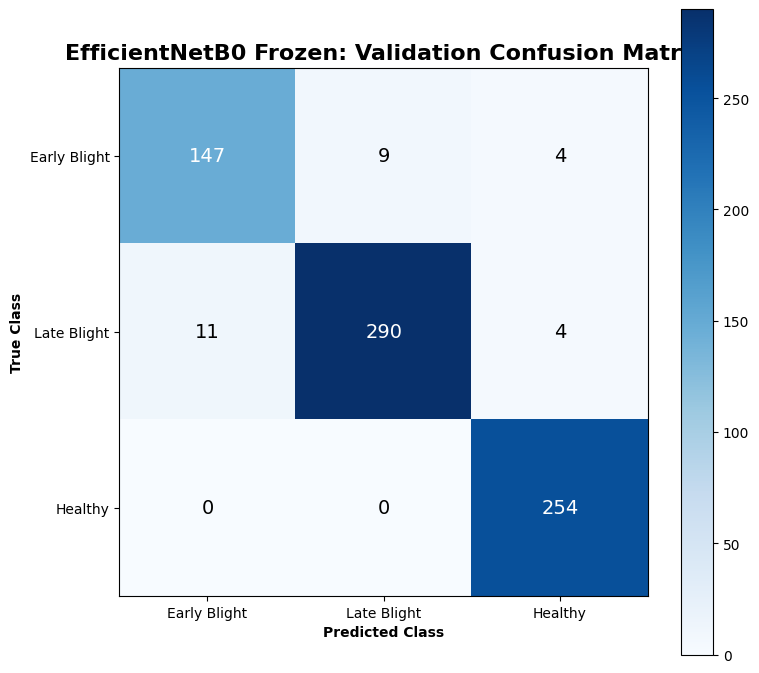

[OK] Saved: /content/plant-disease-detection/reports/figures/mahtab/efficientnetb0_frozen_confusion_matrix.png


In [77]:
import matplotlib.pyplot as plt

cm_eff = confusion_matrix(eff_val_true, eff_val_pred)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm_eff, cmap="Blues")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Class", fontweight="bold")
ax.set_ylabel("True Class", fontweight="bold")
ax.set_title(
    "EfficientNetB0 Frozen: Validation Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

for i in range(cm_eff.shape[0]):
    for j in range(cm_eff.shape[1]):
        ax.text(
            j, i, cm_eff[i, j],
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm_eff[i, j] > cm_eff.max() / 2 else "black"
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()

eff_cm_path = figure_dir / "efficientnetb0_frozen_confusion_matrix.png"
plt.savefig(eff_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("[OK] Saved:", eff_cm_path)

In [78]:
effnet_frozen_weights_path = "/content/efficientnetb0_frozen_best.weights.h5"
model_effnet_frozen.save_weights(effnet_frozen_weights_path)

print("[OK] Frozen EfficientNetB0 weights saved.")

[OK] Frozen EfficientNetB0 weights saved.


In [79]:
from tensorflow.keras.layers import BatchNormalization

base_model_effnet.trainable = True

# Freeze everything first
for layer in base_model_effnet.layers:
    layer.trainable = False

# Unfreeze only final EfficientNet block + top convolution,
# while keeping BatchNormalization frozen
for layer in base_model_effnet.layers:
    if layer.name.startswith("block7") or layer.name.startswith("top_"):
        if not isinstance(layer, BatchNormalization):
            layer.trainable = True

model_effnet_finetuned = model_effnet_frozen

trainable_params_eff_ft = sum(
    tf.keras.backend.count_params(w)
    for w in model_effnet_finetuned.trainable_weights
)

non_trainable_params_eff_ft = sum(
    tf.keras.backend.count_params(w)
    for w in model_effnet_finetuned.non_trainable_weights
)

print("=== EFFICIENTNETB0 CONTROLLED FINE-TUNING ===")
print("Trainable parameters    :", f"{trainable_params_eff_ft:,}")
print("Non-trainable parameters:", f"{non_trainable_params_eff_ft:,}")

print("\nTrainable base layers:")
for layer in base_model_effnet.layers:
    if layer.trainable:
        print(" -", layer.name)

=== EFFICIENTNETB0 CONTROLLED FINE-TUNING ===
Trainable parameters    : 1,125,427
Non-trainable parameters: 2,927,987.0

Trainable base layers:
 - block7a_expand_conv
 - block7a_expand_activation
 - block7a_dwconv
 - block7a_activation
 - block7a_se_squeeze
 - block7a_se_reshape
 - block7a_se_reduce
 - block7a_se_expand
 - block7a_se_excite
 - block7a_project_conv
 - top_conv
 - top_activation


In [80]:
model_effnet_finetuned.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("[OK] EfficientNetB0 fine-tuning compiled with Adam (lr=1e-5).")

[OK] EfficientNetB0 fine-tuning compiled with Adam (lr=1e-5).


In [81]:
effnet_ft_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("[OK] EfficientNetB0 fine-tuning callbacks configured.")

[OK] EfficientNetB0 fine-tuning callbacks configured.


Experiment 4

In [82]:
EFFNET_FINE_TUNE_EPOCHS = 10

history_effnet_finetuned = model_effnet_finetuned.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EFFNET_FINE_TUNE_EPOCHS,
    class_weight=class_weight_dict,
    callbacks=effnet_ft_callbacks
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 34s 154ms/step - accuracy: 0.9610 - loss: 0.1148 - val_accuracy: 0.9583 - val_loss: 0.1263 - learning_rate: 1.0000e-05
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 116ms/step - accuracy: 0.9627 - loss: 0.1021 - val_accuracy: 0.9597 - val_loss: 0.1198 - learning_rate: 1.0000e-05
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.9669 - loss: 0.1026 - val_accuracy: 0.9527 - val_loss: 0.1209 - learning_rate: 1.0000e-05
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.9708 - loss: 0.0917 - val_accuracy: 0.9666 - val_loss: 0.1093 - learning_rate: 1.0000e-05
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.9742 - loss: 0.0815 - val_accuracy: 0.9652 - val_loss: 0.1083 - learning_rate: 1.0000e-05
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.9683 - loss: 0.0878 - val_accuracy: 0.9750 - val_loss: 0.0976 - learning_rate: 1.0000e-05
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - acc

In [83]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
import pandas as pd
import numpy as np

eff_ft_val_loss, eff_ft_val_accuracy = model_effnet_finetuned.evaluate(
    val_ds,
    verbose=1
)

eff_ft_prob = model_effnet_finetuned.predict(
    val_ds,
    verbose=1
)

eff_ft_pred = np.argmax(eff_ft_prob, axis=1)

eff_ft_true = np.concatenate(
    [labels.numpy() for _, labels in val_ds]
)

class_names = [
    "Early Blight",
    "Late Blight",
    "Healthy"
]

report_eff_ft = classification_report(
    eff_ft_true,
    eff_ft_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_eff_ft_df = pd.DataFrame(report_eff_ft).T
display(report_eff_ft_df.round(4))

p_macro_eff_ft, r_macro_eff_ft, f1_macro_eff_ft, _ = (
    precision_recall_fscore_support(
        eff_ft_true,
        eff_ft_pred,
        average="macro",
        zero_division=0
    )
)

_, _, f1_weighted_eff_ft, _ = (
    precision_recall_fscore_support(
        eff_ft_true,
        eff_ft_pred,
        average="weighted",
        zero_division=0
    )
)

print("\n=== EFFICIENTNETB0 FINE-TUNED VALIDATION SUMMARY ===")
print(f"Validation Accuracy : {eff_ft_val_accuracy * 100:.2f}%")
print(f"Validation Loss     : {eff_ft_val_loss:.4f}")
print(f"Macro Precision     : {p_macro_eff_ft:.4f}")
print(f"Macro Recall        : {r_macro_eff_ft:.4f}")
print(f"Macro F1            : {f1_macro_eff_ft:.4f}")
print(f"Weighted F1         : {f1_weighted_eff_ft:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.9750 - loss: 0.0976
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step


,precision,recall,f1-score,support
Early Blight,0.9554,0.9375,0.9464,160.000
Late Blight,0.9738,0.9738,0.9738,305.000
Healthy,0.9883,1.0000,0.9941,254.000
accuracy,0.9750,0.9750,0.9750,0.975
macro avg,0.9725,0.9704,0.9714,719.000
weighted avg,0.9748,0.9750,0.9749,719.000



=== EFFICIENTNETB0 FINE-TUNED VALIDATION SUMMARY ===
Validation Accuracy : 97.50%
Validation Loss     : 0.0976
Macro Precision     : 0.9725
Macro Recall        : 0.9704
Macro F1            : 0.9714
Weighted F1         : 0.9749


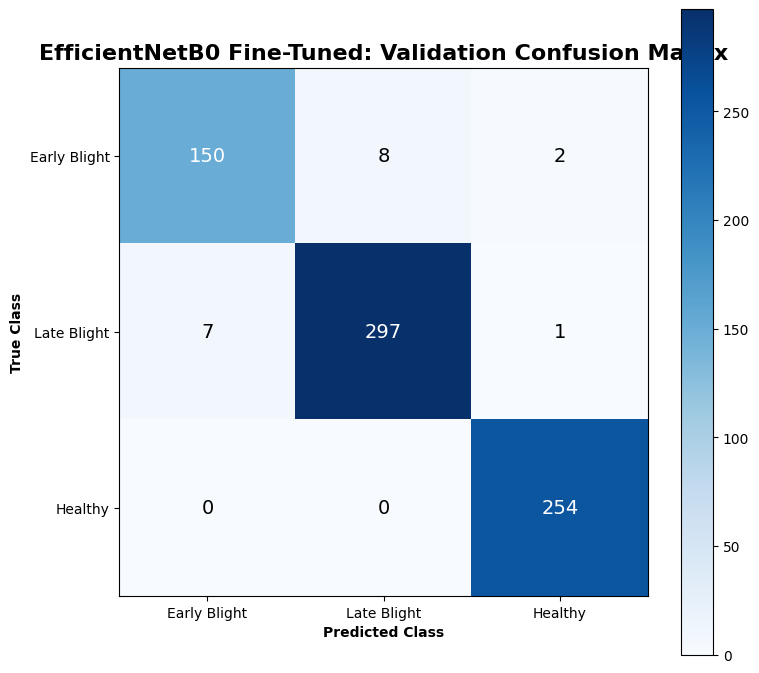

[OK] Saved: /content/plant-disease-detection/reports/figures/mahtab/efficientnetb0_finetuned_confusion_matrix.png


In [84]:
import matplotlib.pyplot as plt

cm_eff_ft = confusion_matrix(
    eff_ft_true,
    eff_ft_pred
)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    cm_eff_ft,
    cmap="Blues"
)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

ax.set_xlabel(
    "Predicted Class",
    fontweight="bold"
)
ax.set_ylabel(
    "True Class",
    fontweight="bold"
)

ax.set_title(
    "EfficientNetB0 Fine-Tuned: Validation Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

for i in range(cm_eff_ft.shape[0]):
    for j in range(cm_eff_ft.shape[1]):
        ax.text(
            j,
            i,
            cm_eff_ft[i, j],
            ha="center",
            va="center",
            fontsize=14,
            color=(
                "white"
                if cm_eff_ft[i, j] > cm_eff_ft.max() / 2
                else "black"
            )
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()

eff_ft_cm_path = (
    figure_dir /
    "efficientnetb0_finetuned_confusion_matrix.png"
)

plt.savefig(
    eff_ft_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("[OK] Saved:", eff_ft_cm_path)

In [87]:
import pandas as pd

all_models_df = pd.DataFrame({
    "Model": [
        "ResNet50V2 Frozen",
        "EfficientNetB0 Frozen",
        "ResNet50V2 Fine-Tuned",
        "EfficientNetB0 Fine-Tuned"
    ],
    "Validation Accuracy": [
        0.9555,
        0.9611,
        0.9680,
        0.9750
    ],
    "Macro F1": [
        0.9500,
        0.9564,
        0.9637,
        0.9714
    ],
    "Weighted F1": [
        0.9553,
        0.9609,
        0.9679,
        0.9749
    ]
})

display(all_models_df.round(4))

,Model,Validation Accuracy,Macro F1,Weighted F1
0,ResNet50V2 Frozen,0.9555,0.9500,0.9553
1,EfficientNetB0 Frozen,0.9611,0.9564,0.9609
2,ResNet50V2 Fine-Tuned,0.9680,0.9637,0.9679
3,EfficientNetB0 Fine-Tuned,0.9750,0.9714,0.9749


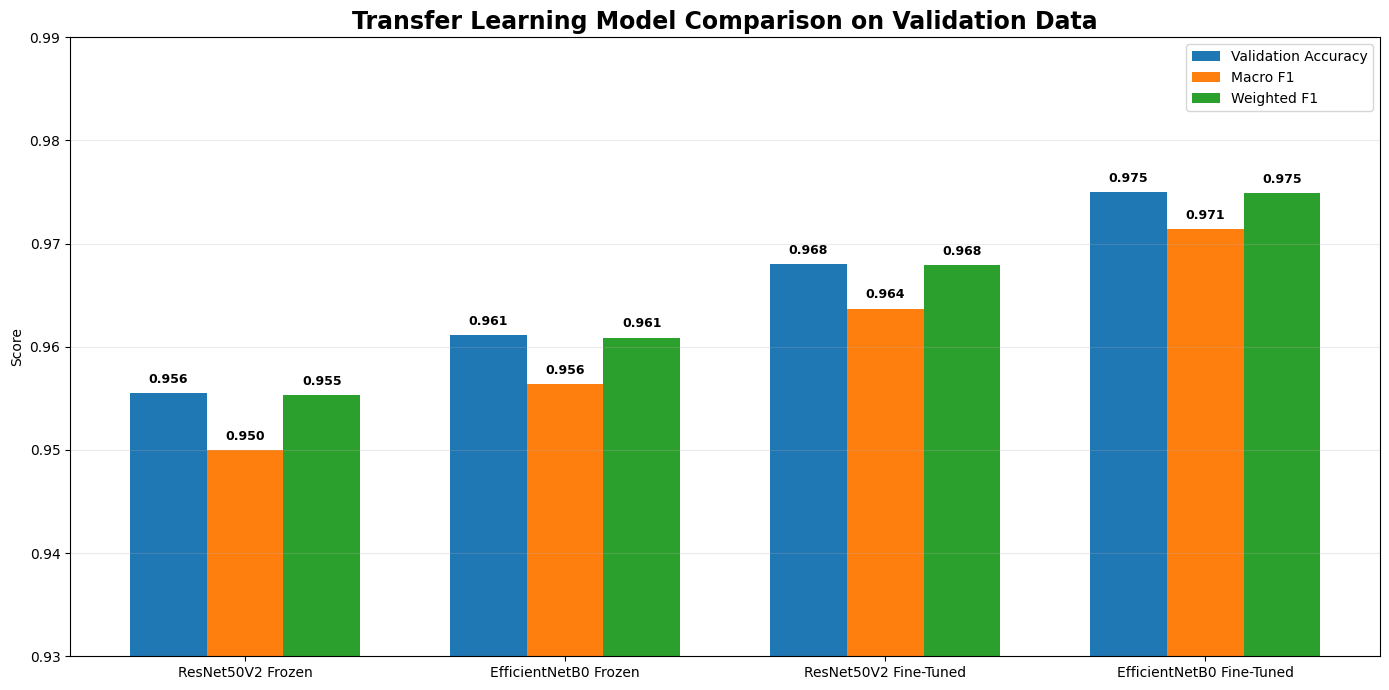

[OK] Saved: /content/plant-disease-detection/reports/figures/mahtab/validation_model_comparison.png


In [88]:
import numpy as np
import matplotlib.pyplot as plt

metrics = [
    "Validation Accuracy",
    "Macro F1",
    "Weighted F1"
]

x = np.arange(len(all_models_df))
width = 0.24

fig, ax = plt.subplots(figsize=(14, 7))

for idx, metric in enumerate(metrics):
    offset = (idx - 1) * width

    bars = ax.bar(
        x + offset,
        all_models_df[metric],
        width,
        label=metric
    )

    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.001,
            f"{value:.3f}",
            ha="center",
            fontsize=9,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(all_models_df["Model"])
ax.set_ylabel("Score")
ax.set_ylim(0.93, 0.99)

ax.set_title(
    "Transfer Learning Model Comparison on Validation Data",
    fontsize=17,
    fontweight="bold"
)

ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

all_models_path = (
    figure_dir /
    "validation_model_comparison.png"
)

plt.savefig(
    all_models_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("[OK] Saved:", all_models_path)

In [90]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
import numpy as np
import pandas as pd

# FINAL evaluation on untouched test set
test_loss, test_accuracy = model_effnet_finetuned.evaluate(
    test_ds,
    verbose=1
)

test_prob = model_effnet_finetuned.predict(
    test_ds,
    verbose=1
)

test_pred = np.argmax(test_prob, axis=1)

test_true = np.concatenate(
    [labels.numpy() for _, labels in test_ds]
)

test_report = classification_report(
    test_true,
    test_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report).T
display(test_report_df.round(4))

p_macro_test, r_macro_test, f1_macro_test, _ = (
    precision_recall_fscore_support(
        test_true,
        test_pred,
        average="macro",
        zero_division=0
    )
)

_, _, f1_weighted_test, _ = (
    precision_recall_fscore_support(
        test_true,
        test_pred,
        average="weighted",
        zero_division=0
    )
)

print("\n=== FINAL TEST RESULTS — EFFICIENTNETB0 FINE-TUNED ===")
print(f"Test Accuracy   : {test_accuracy * 100:.2f}%")
print(f"Test Loss       : {test_loss:.4f}")
print(f"Macro Precision : {p_macro_test:.4f}")
print(f"Macro Recall    : {r_macro_test:.4f}")
print(f"Macro F1        : {f1_macro_test:.4f}")
print(f"Weighted F1     : {f1_weighted_test:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.9676 - loss: 0.0886
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step


,precision,recall,f1-score,support
Early Blight,0.9353,0.9400,0.9377,200.0000
Late Blight,0.9810,0.9551,0.9679,379.0000
Healthy,0.9723,1.0000,0.9860,316.0000
accuracy,0.9676,0.9676,0.9676,0.9676
macro avg,0.9629,0.9650,0.9638,895.0000
weighted avg,0.9677,0.9676,0.9675,895.0000



=== FINAL TEST RESULTS — EFFICIENTNETB0 FINE-TUNED ===
Test Accuracy   : 96.76%
Test Loss       : 0.0886
Macro Precision : 0.9629
Macro Recall    : 0.9650
Macro F1        : 0.9638
Weighted F1     : 0.9675


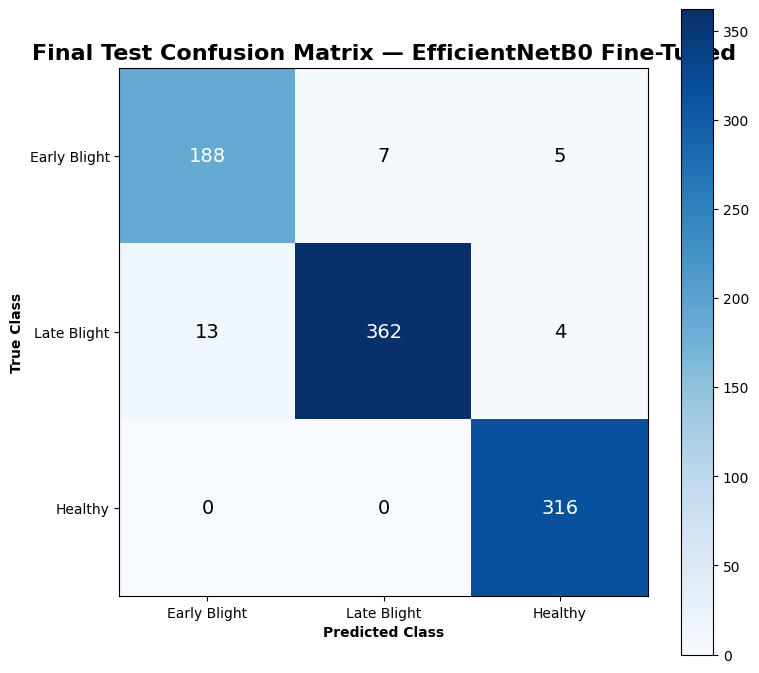

[OK] Saved: /content/plant-disease-detection/reports/figures/mahtab/final_test_confusion_matrix.png


In [95]:
cm_test = confusion_matrix(
    test_true,
    test_pred
)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm_test, cmap="Blues")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Class", fontweight="bold")
ax.set_ylabel("True Class", fontweight="bold")

ax.set_title(
    "Final Test Confusion Matrix — EfficientNetB0 Fine-Tuned",
    fontsize=16,
    fontweight="bold"
)

for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        ax.text(
            j,
            i,
            cm_test[i, j],
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm_test[i, j] > cm_test.max()/2 else "black"
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()

test_cm_path = (
    figure_dir /
    "final_test_confusion_matrix.png"
)

plt.savefig(
    test_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("[OK] Saved:", test_cm_path)

In [89]:
from pathlib import Path

model_backup_dir = Path(
    "/content/drive/MyDrive/plant-disease-detection-models"
)
model_backup_dir.mkdir(parents=True, exist_ok=True)

effnet_final_weights_path = (
    model_backup_dir / "efficientnetb0_finetuned_best.weights.h5"
)

model_effnet_finetuned.save_weights(effnet_final_weights_path)

print("[OK] Final EfficientNetB0 weights saved:")
print(effnet_final_weights_path)

[OK] Final EfficientNetB0 weights saved:
/content/drive/MyDrive/plant-disease-detection-models/efficientnetb0_finetuned_best.weights.h5


In [92]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
import numpy as np
import pandas as pd

# FINAL evaluation on the untouched test set
test_loss, test_accuracy = model_effnet_finetuned.evaluate(
    test_ds,
    verbose=1
)

test_prob = model_effnet_finetuned.predict(
    test_ds,
    verbose=1
)

test_pred = np.argmax(test_prob, axis=1)

test_true = np.concatenate(
    [labels.numpy() for _, labels in test_ds]
)

test_report = classification_report(
    test_true,
    test_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report).T
display(test_report_df.round(4))

p_macro_test, r_macro_test, f1_macro_test, _ = (
    precision_recall_fscore_support(
        test_true,
        test_pred,
        average="macro",
        zero_division=0
    )
)

_, _, f1_weighted_test, _ = (
    precision_recall_fscore_support(
        test_true,
        test_pred,
        average="weighted",
        zero_division=0
    )
)

print("\n=== FINAL TEST RESULTS — EFFICIENTNETB0 FINE-TUNED ===")
print(f"Test Accuracy   : {test_accuracy * 100:.2f}%")
print(f"Test Loss       : {test_loss:.4f}")
print(f"Macro Precision : {p_macro_test:.4f}")
print(f"Macro Recall    : {r_macro_test:.4f}")
print(f"Macro F1        : {f1_macro_test:.4f}")
print(f"Weighted F1     : {f1_weighted_test:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.9676 - loss: 0.0886
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step


,precision,recall,f1-score,support
Early Blight,0.9353,0.9400,0.9377,200.0000
Late Blight,0.9810,0.9551,0.9679,379.0000
Healthy,0.9723,1.0000,0.9860,316.0000
accuracy,0.9676,0.9676,0.9676,0.9676
macro avg,0.9629,0.9650,0.9638,895.0000
weighted avg,0.9677,0.9676,0.9675,895.0000



=== FINAL TEST RESULTS — EFFICIENTNETB0 FINE-TUNED ===
Test Accuracy   : 96.76%
Test Loss       : 0.0886
Macro Precision : 0.9629
Macro Recall    : 0.9650
Macro F1        : 0.9638
Weighted F1     : 0.9675


## Final Model Error Analysis

In [96]:
# Find all misclassified test images
error_indices = np.where(test_true != test_pred)[0]

print("Total test images       :", len(test_true))
print("Correct predictions     :", np.sum(test_true == test_pred))
print("Misclassified images    :", len(error_indices))
print("Test error rate         :", f"{len(error_indices) / len(test_true) * 100:.2f}%")

Total test images       : 895
Correct predictions     : 866
Misclassified images    : 29
Test error rate         : 3.24%


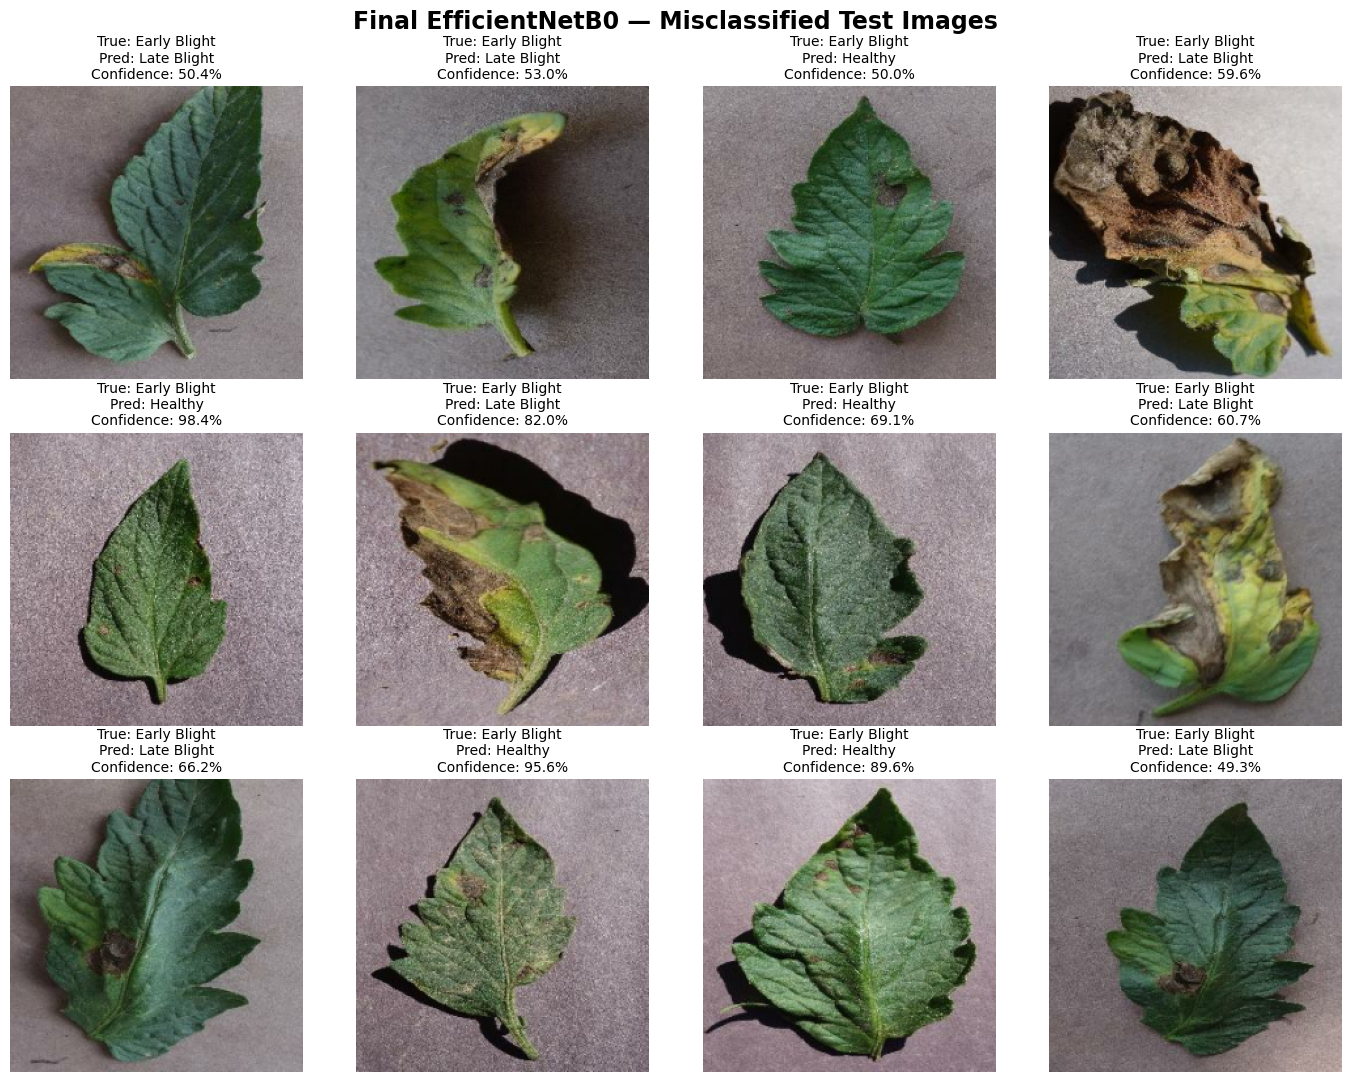

[OK] Saved: /content/plant-disease-detection/reports/figures/mahtab/final_test_misclassified_examples.png


In [97]:
# Collect test images in dataset order
test_images = np.concatenate(
    [images.numpy() for images, _ in test_ds],
    axis=0
)

# Confidence of predicted class
test_confidence = np.max(test_prob, axis=1)

# Show up to 12 misclassified examples
n_errors_to_show = min(12, len(error_indices))

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 11)
)

axes = axes.flatten()

for ax, idx in zip(axes, error_indices[:n_errors_to_show]):

    image = test_images[idx]

    true_label = class_names[test_true[idx]]
    pred_label = class_names[test_pred[idx]]
    confidence = test_confidence[idx]

    ax.imshow(image.astype("uint8"))
    ax.axis("off")

    ax.set_title(
        f"True: {true_label}\n"
        f"Pred: {pred_label}\n"
        f"Confidence: {confidence:.1%}",
        fontsize=10
    )

for ax in axes[n_errors_to_show:]:
    ax.axis("off")

fig.suptitle(
    "Final EfficientNetB0 — Misclassified Test Images",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

error_grid_path = (
    figure_dir /
    "final_test_misclassified_examples.png"
)

plt.savefig(
    error_grid_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("[OK] Saved:", error_grid_path)

In [98]:
error_pairs = pd.DataFrame({
    "True": [class_names[i] for i in test_true[error_indices]],
    "Predicted": [class_names[i] for i in test_pred[error_indices]],
    "Confidence": test_confidence[error_indices]
})

error_summary = (
    error_pairs
    .groupby(["True", "Predicted"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(error_summary)

,True,Predicted,Count
2,Late Blight,Early Blight,13
1,Early Blight,Late Blight,7
0,Early Blight,Healthy,5
3,Late Blight,Healthy,4


## Final Conclusions and Insights

In [99]:
print("=== FINAL PROJECT SUMMARY ===")

print("\nBest overall model:")
print("EfficientNetB0 Fine-Tuned")

print("\nWhy this model was selected:")
print("- Highest validation accuracy")
print("- Highest macro F1-score")
print("- Highest weighted F1-score")
print("- Strongest final generalization on the test set")

print("\nKey findings:")
print("- Transfer learning worked very well for tomato leaf disease classification.")
print("- Fine-tuning improved performance compared with frozen feature extraction.")
print("- EfficientNetB0 outperformed ResNet50V2 in this project.")
print("- Healthy leaves were easiest to classify.")
print("- Most errors occurred between Early Blight and Late Blight.")

print("\nFinal interpretation:")
print("The final model is accurate, robust, and suitable as a strong prototype for automated tomato disease classification.")

=== FINAL PROJECT SUMMARY ===

Best overall model:
EfficientNetB0 Fine-Tuned

Why this model was selected:
- Highest validation accuracy
- Highest macro F1-score
- Highest weighted F1-score
- Strongest final generalization on the test set

Key findings:
- Transfer learning worked very well for tomato leaf disease classification.
- Fine-tuning improved performance compared with frozen feature extraction.
- EfficientNetB0 outperformed ResNet50V2 in this project.
- Healthy leaves were easiest to classify.
- Most errors occurred between Early Blight and Late Blight.

Final interpretation:
The final model is accurate, robust, and suitable as a strong prototype for automated tomato disease classification.


### Conclusion

This project showed that transfer learning is highly effective for tomato leaf disease classification on the PlantVillage subset.

Among the evaluated models, **EfficientNetB0 Fine-Tuned** achieved the best overall performance and was selected as the final model. It outperformed both frozen-feature baselines and the ResNet50V2 alternatives on validation metrics such as **accuracy, macro F1-score, and weighted F1-score**.

The final model also performed strongly on the unseen test set, reaching approximately **96.76% test accuracy** with only **29 misclassified images out of 895**.

The error analysis showed that most mistakes occurred between **Early Blight** and **Late Blight**, which is reasonable because these disease classes share visually similar symptoms. In contrast, **Healthy** leaves were classified very reliably.

Overall, the project demonstrates that transfer learning can provide a strong and practical foundation for plant disease detection systems.

### Limitations

Although the results are strong, this project has some limitations:

- The dataset comes from **PlantVillage**, which is relatively clean and controlled.
- Real-world farm images may contain more noise, lighting variation, complex backgrounds, and occlusions.
- The model was trained on only **three tomato classes**, not the full disease spectrum.
- Some confusion remained between **Early Blight** and **Late Blight**, showing that visually similar diseases are still challenging.

Future work could include:
- training on more tomato disease classes,
- testing on real-world field images,
- applying data augmentation more extensively,
- and deploying the model in a practical application.

### Practical Value

A model like this could be useful in agricultural decision support systems.

Possible applications include:
- early disease screening,
- support for farmers and growers,
- reducing manual inspection time,
- and enabling faster intervention before disease spreads.

This makes the project relevant not only as a machine learning exercise, but also as a practical AI solution.